In [63]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Day 1  _ missing part 2 and 3

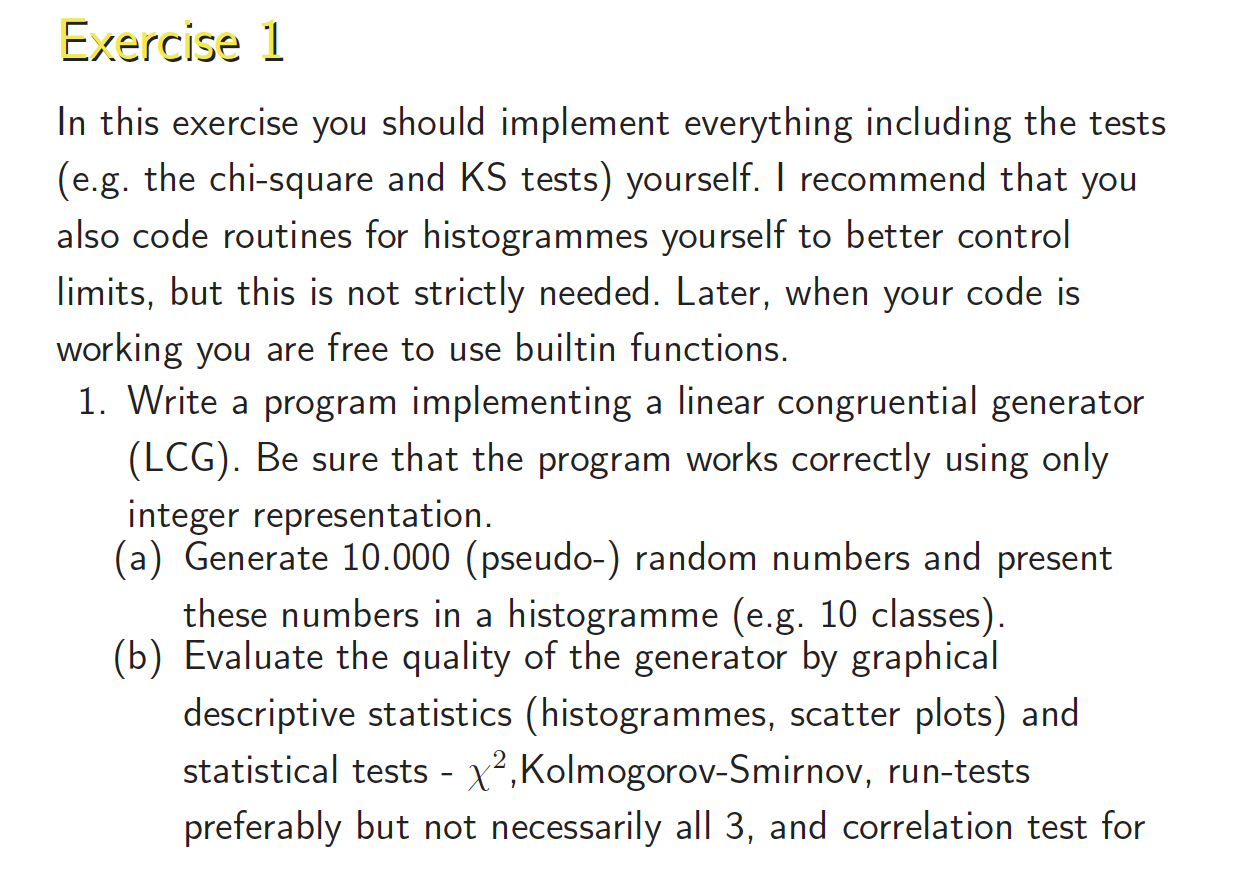

Linear congurential generator (LCG) is defined by $x_i = mod(ax_{i-1}+c, M)$

where, a is the multiplier, c is the increment, M is the modulus.

## (a) Generate 10.000 (pseudo-) random numbers and present these numbers in a histogramme (e.g. 10 classes).

In [64]:
a = 1203515245
c =12345
M = 2**32
# Linear Congurential Generator
def LCG(x0,a,c,M,n):
    x= x0
    numbers = []
    for i in range(n):
        x = (a*x+c)%M
        U=x/M
        numbers.append(U)
    return numbers
LCG(3,a,c,M,10000)

[0.8406485617160797,
 0.7126281692180783,
 0.6703997845761478,
 0.9821126086171716,
 0.7774873180314898,
 0.045064297737553716,
 0.3323677801527083,
 0.36059573176316917,
 0.4589076992124319,
 0.05003916868008673,
 0.35361378407105803,
 0.9716593825723976,
 0.8731706896796823,
 0.5166646346915513,
 0.4036407698877156,
 0.06340551073662937,
 0.7885474972426891,
 0.3381747102830559,
 0.29911891696974635,
 0.6409818117972463,
 0.26570968981832266,
 0.4405754741746932,
 0.7423499659635127,
 0.1623214732389897,
 0.6339865196496248,
 0.5228184091392905,
 0.7657862617634237,
 0.4438438580837101,
 0.6033644350245595,
 0.8428721793461591,
 0.4294794839806855,
 0.3854911259841174,
 0.9341037794947624,
 0.03406784520484507,
 0.06833406491205096,
 0.874475791817531,
 0.8358476785942912,
 0.6860925157088786,
 0.13604029500856996,
 0.9771142217796296,
 0.01809811405837536,
 0.17500643827952445,
 0.44256211584433913,
 0.27812106697820127,
 0.06393418554216623,
 0.9766585261095315,
 0.3320546005852520

3610558080
3060714681
2879345150
4218141535
3339282604
193549685
1427508746
1548746875
1970993560
214916593
1518759638
4173245271
3750239556
2219057709
1733623906
272324595
3386785712
1452449321
1284705966
2752995919
1141214428
1892257253
3188368826
697165419
2722951368
2245487969
3289026950
1906294855
2591430516
3620108445
1844600338
1655671779
4011945184
146320281
293492574
3755844927
3589938444
2946744917
584288618
4196673627
77730808
751646929
1900789814
1194520887
274595236
4194716429
1426163650
4195064787
2357282320
1923609865
421276686
425559087
328866108
3478057669
2933635354
4020356683
660431656
3512188993
1969552102
2432122407
2471677908
1511692669
2722987378
314476483
3191917376
3924261497
2531757246
3505782559
374899052
3267501877
776877258
3713384507
2216812120
719193009
3492888982
1949017879
2418511364
182084589
3563142946
318197683
2808282224
3820895209
2199615854
2361792015
2858964380
3635693477
3189111930
944707115
3008529800
1216807713
508269638
332344327
3194959924
8

(array([ 985.,  902.,  977., 1060., 1017., 1029., 1027.,  949., 1012.,
        1042.]),
 array([7.55286310e-05, 1.00057015e-01, 2.00038501e-01, 3.00019986e-01,
        4.00001472e-01, 4.99982958e-01, 5.99964444e-01, 6.99945930e-01,
        7.99927416e-01, 8.99908902e-01, 9.99890388e-01]),
 <BarContainer object of 10 artists>)

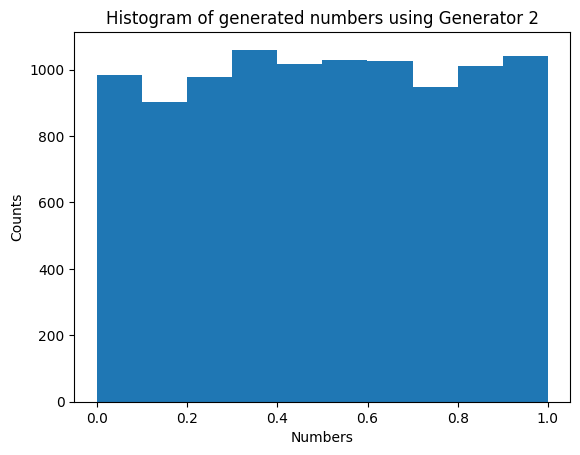

In [65]:

# Linear Congurential Generator

def LCG(x0,a,c,M,n):
    x= x0
    numbers = []
    for i in range(n):
        x = (a*x+c)%M
        print(x)
        U=x/M
        numbers.append(U)
    return numbers

#a=5
#M = 16
x0=3
#c=1
S= 10000

a = 1203515245
c =12345
M = 2**32


numbers= LCG(x0,a,c,M,S)
# I get 3, 0, 1, 6 ... like they did in the slides. 
plt.title("Histogram of generated numbers using Generator 2")
plt.xlabel("Numbers")
plt.ylabel("Counts")
plt.hist(numbers,10)

## (b)
Evaluate the quality of the generator by graphical
descriptive statistics (histogrammes, scatter plots) and
statistical tests -  2,Kolmogorov-Smirnov, run-tests
preferably but not necessarily all 3, and correlation test for some h-values.

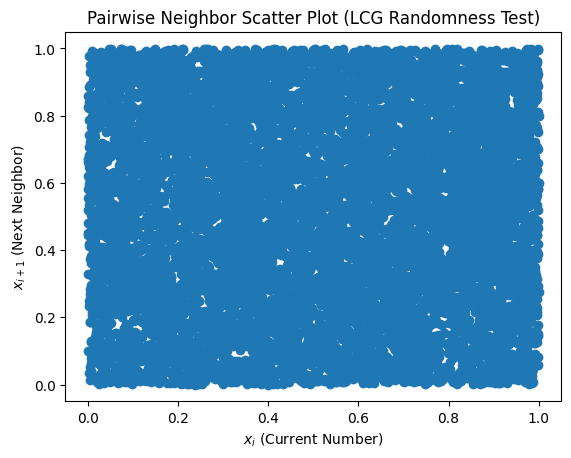

In [66]:

x = np.linspace(0,1,10000)
#now i plot neigboors pairwise
plt.scatter(numbers[:-1],numbers[1:])
# Add titles and labels
plt.title("Pairwise Neighbor Scatter Plot (LCG Randomness Test)")
plt.xlabel("$x_i$ (Current Number)")
plt.ylabel("$x_{i+1}$ (Next Neighbor)")
plt.show()

#### $X^2$ test

the genereal form of the test statistic is 

$ T = \sum_{i=1}^{^n classes} \frac{n_{observed,i} -n_{expected}}{n_{expected,i}}$

In [67]:
#Qhi squared test

m = 0 # number of estimated parameters is zero since have not estimated anything we just choose it ( a, c, M)

# i need to sort the numbers list: 
num_sort = np.sort(numbers)


bins = 10

observed, _ = np.histogram(num_sort, bins=bins)
print(observed)

expected = np.ones(bins) * (S / bins)
print(expected)

def chi_square(n_observed, n_expected, m):

    T = np.sum((n_observed-n_expected)**2/n_expected)
    print(T)
    n_classes = len(n_observed)
    df = n_classes -1 - m

    # Calculate the theoretical Chi-Squared PDF
    pdf = 1-stats.chi2.cdf(T, df)
    pdf2 = stats.chi2.sf(T, df)
    return pdf, pdf2

    
chi_square(observed, expected, m)




[ 985  902  977 1060 1017 1029 1027  949 1012 1042]
[1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.]
20.325999999999997


(np.float64(0.016003738734274298), np.float64(0.016003738734274343))

So T says somthing about how similar our distribution is compared to the Chi2 distribution(?)
So a very low P value means is very unlikly that we observe this if it was truely uniform. 

### now for the Kolmogorovs distribution

$ D_n = \sup_{x}\{| F_n(x)-F(x)|\}$

Supremun ( largest value in set for open sets its the limit value, for closd s
sets its the max.) F is the cdf. 

We have our cdf for the uniform. we need to compare this to where we have our divisions, 

In [68]:

# Empirical cdf is what is based on our numbers, 
# and x is where on the x axis ( between 0 and 
# what he take the cdf from, so if we pick x=1
# then 100 percent of the values will be less 
# than or equal to this. )
def empirical_cdf(x, num_sort):
    numbers = np.array(num_sort)
    F_emp = []
    for val in x:
        count = np.sum(numbers <= val) / len(numbers)
        F_emp.append(count)
    return np.array(F_emp) #np.sum(numbers <= x)/len(numbers)

# Uniform destribtuion
def uniform_cdf(x):
    F = []
    for i in range(len(x)):
        if x[i] < 0: 
            F.append(0)
        if 0 < x[i] < 1:
            F.append((x - 0)/(1-0))
        if x[i] > 1:
            F.append(1)
    return np.array(F)

x = np.linspace(0,1,S)
def Kolmogorovs_dist(x, num_sort):
    D = np.max(np.abs(empirical_cdf(x, num_sort)-uniform_cdf(x)))
    return D

D_n=Kolmogorovs_dist(x, num_sort)

# have to standardize it in order to see where it fits in the table: 
#(sqrt(n) + 0.12 + 0.11/sqrt(n))D_n
standard = (np.sqrt(S) + 0.12+0.11/np.sqrt(S))*D_n
standard

np.float64(1.564614728898891)

This is really bad, but also expected since we repeat the same 16 numbers again and again and again. this is equivalent to have a really low p value. 

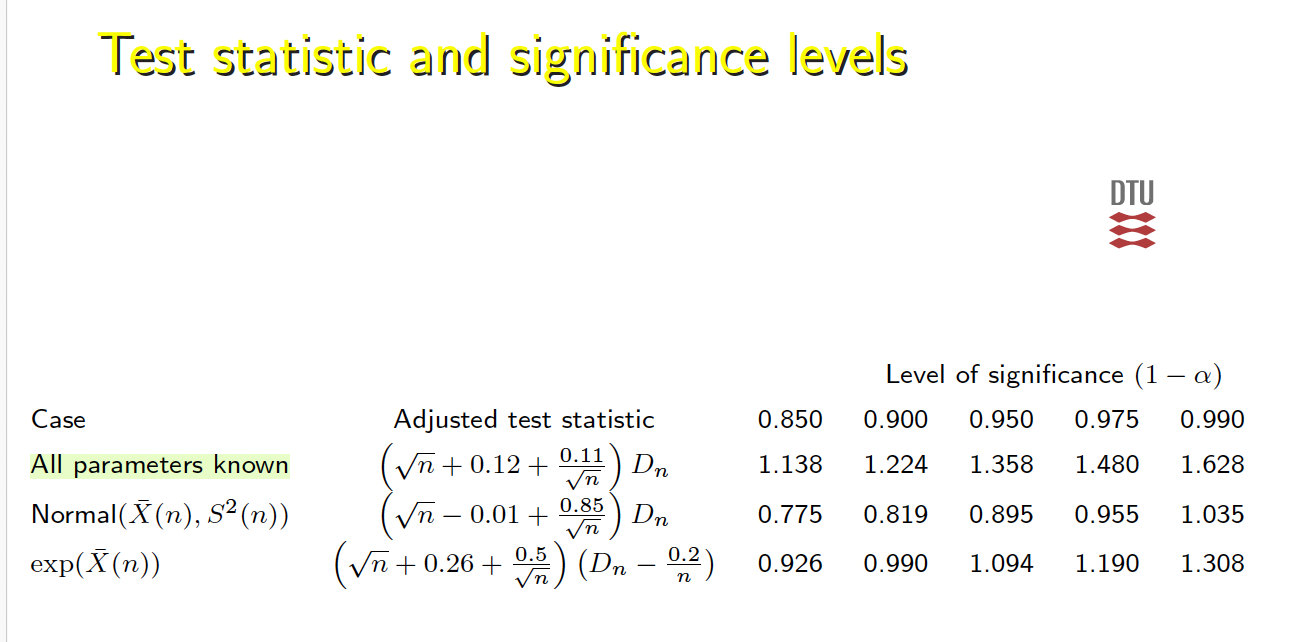

### Run tests

Wald-Wolfowitz

we calculate a 

Run test I

The Wald-Wolfowitz run test, can be used by e.g. comparing with
the median. The number of runs (above/below the median) is (asymptotically)
distributed as

$$ Normal (2 \frac{n_1n_2}{n_1+n_2}+1, 2\frac{n_1n_2(2n_1n_2-n_1-n_2)}{(n_1+n_2)^2(n_1+n_2-1)})$$

where n1 is the number of samples above and n2 is the number
below. 
• The test statistic is the total number of runs T = Ra +Rb with Ra
(runs above) and Rb (runs below)

A run is every time like above and bellow, so if its above, above, above, bellow, bellow, there is 2 runs. 


In [69]:
def Wald_Wolfowiz(numbers):
    median = np.median(numbers)
    n_1= np.sum(numbers >= median)
    n_2= np.sum(numbers < median)
    # this is the normal dfistribution of how many runs there should be.
    mu = 2*(n_1*n_2)/(n_1+n_2)
    var = n_1*n_2*(2*n_1*n_2-n_1-n_2)/((n_1+n_2)**2*(n_1+n_2-1))
    #remeber to use unsorted numbers especially for the runs

    label = ["Above" if i >= median else "Below" for i in numbers]

    T = 1 # T is Runns above plus runns below , this is how many runs there actually is.
    for i in range(1, len(label)):
        if label[i] != label[i -1]:
            T += 1
    return mu, var, T

mu, var, T = Wald_Wolfowiz(numbers)

standard_T = (T-mu)/(np.sqrt(var))
mu, var, T

(np.float64(5000.0), np.float64(1249.87498749875), 4956)

In [70]:
# So this is how you would do it if you *think* about the numbers
# i have not standardised T here, so its all positive, 
# i know that my T is below the median ( 3751 < 5000) so that is why i dont need to substract the 1
cdf = 2*stats.norm.cdf(T, mu, np.sqrt(var))
cdf

np.float64(0.21328979064234344)

In [71]:
# Here this is the genereal "always right way" we standardise T using the Mu and Var calulated, and we use the Abs of the standard T, and we minus 1. 
cdf = 2*(1-stats.norm.cdf(np.abs(standard_T), 0, 1))
cdf

np.float64(0.21328979064234344)

### Up/Down from Knuth

In [72]:
# New new Knuth working
def knuth(obs):
    obs = np.array(obs)
    n = len(obs)

    # --- Step 1: compute increasing runs ---
    lengths = []
    current_len = 1

    for i in range(1, n):
        if obs[i] > obs[i - 1]:
            current_len += 1
        else:
            lengths.append(current_len)
            current_len = 1

    

    R = np.zeros(6)
    for r in lengths:
        if r <= 5: 
            R[r-1] += 1 
        else: 
            R[5] += 1 
    
    A = np.array([
    [4529.4,  9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
    ])

    B = np.array([
    [1/6],
    [5/24],
    [11/120],
    [19/720],
    [29/5040],
    [1/840]
    ])

    
    d = R - n*B.flatten()
    Z = (d.T @ A @ d) / (n - 6)
    


    
    df = 6
    p_value = chi2.sf(Z,df)
  
    return p_value
            
    


#-----Old knuth not working
def run_UpDown_Knuth(numbers):
    median = np.median(numbers)
    label = ["Above" if i >= median else "Below" for i in numbers]

    T = 1 # Total amount of Runs 
    run_lengths = []  #run length
    current_run_lenght = 1

    for i in range(1, len(label)):
        #increasing run by one when the run its "continued"
        if label[i] == label[i-1]:
            current_run_lenght += 1
        else: 
            #new run
            run_lengths.append(current_run_lenght)
            # remeber to reset the run lenght count
            current_run_lenght = 1
            T += 1

    run_lengths.append(current_run_lenght)
    R = [run_lengths.count(1), run_lengths.count(2),run_lengths.count(3), run_lengths.count(4), run_lengths.count(5), run_lengths.count(6) ]

    # Now calculating N
    A = np.array([
    [4529.4,  9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
    ])

    B = np.array([
    [1/6],
    [5/24],
    [11/120],
    [19/720],
    [29/5040],
    [1/840]
    ]).flatten()

    n = len(numbers)
    R = np.array(R)
    Z = 1/(n-6)*((R-n*B).T)@A@(R-n*B)


    return T, R,Z

T, R, Z= run_UpDown_Knuth(numbers)

R,Z
    

(array([2425, 1261,  656,  299,  165,   73]), np.float64(171900.5792761875))

In [73]:
# we now compare with a qhi square distribution with degrees of freedom 6
stats.chi2.sf(Z, 6)
#p-value of 0 means that our null hypothesis (of this being a uniform distribution) very likely can be discarded. 

np.float64(0.0)

### Correlation coefficients - h-values

In [74]:



def correlation_coef(num,h):
    n= len(num)
    num= np.array(num)
    c = 1/(n-h)*np.sum(num[:-h]*num[h:])
    c_std = np.abs((c-0.25)/np.sqrt((7/(144*n))))
    return 2*(stats.norm.sf(c_std))
#h is the lag, the larger the h the bigger the rejection. 
correlation_coef(numbers,5)

np.float64(0.014333512957849072)

### (c) Repeat (a) and (b) by experimenting with different values of “a”, “b” and “M”. In the end you should have a decent generator. Report at least one bad and your final choice.

I changed all above to from a=5, x0=3, c=1, M=16

to M=10^8+1, a = 23, c = 1

### 2. Apply a system available generator and perform the various statistical tests you did under Part 1 point (b) for this generator too.

In [75]:
# a system avaiable generator is numpys random generator

Samples2= np.random()

TypeError: 'module' object is not callable

### 3. You were asked to simulate one sample and perform tests on this sample. Discuss the sufficiency of this approach and take action, if needed.

# Day 2

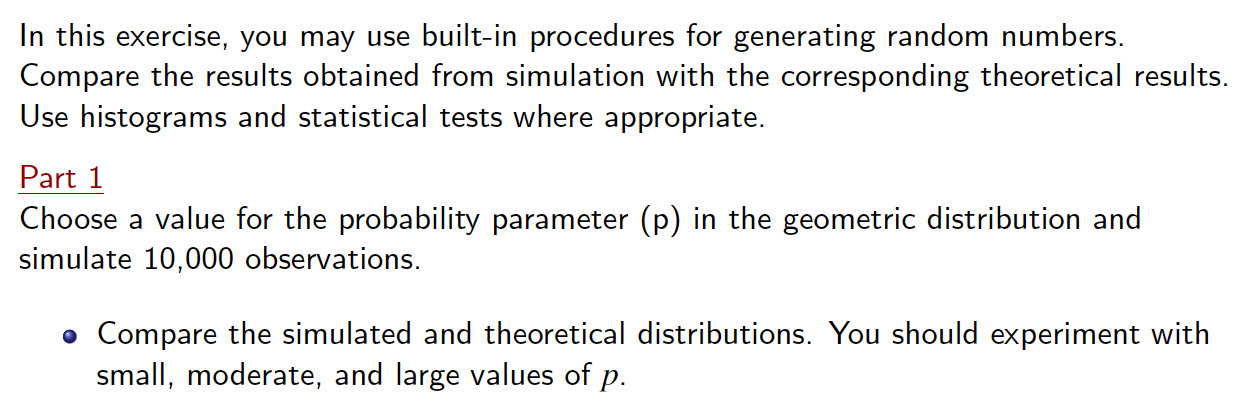

(array([2.599e+03, 0.000e+00, 1.980e+03, 0.000e+00, 0.000e+00, 1.484e+03,
        0.000e+00, 0.000e+00, 1.043e+03, 0.000e+00, 0.000e+00, 7.760e+02,
        0.000e+00, 5.740e+02, 0.000e+00, 0.000e+00, 4.070e+02, 0.000e+00,
        0.000e+00, 2.980e+02, 0.000e+00, 0.000e+00, 2.370e+02, 0.000e+00,
        0.000e+00, 1.730e+02, 0.000e+00, 1.210e+02, 0.000e+00, 0.000e+00,
        8.100e+01, 0.000e+00, 0.000e+00, 6.400e+01, 0.000e+00, 0.000e+00,
        4.000e+01, 0.000e+00, 4.800e+01, 0.000e+00, 0.000e+00, 2.000e+01,
        0.000e+00, 0.000e+00, 1.800e+01, 0.000e+00, 0.000e+00, 9.000e+00,
        0.000e+00, 0.000e+00, 4.000e+00, 0.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 4.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 3.000e+00, 0.000e+00, 3.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        4.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

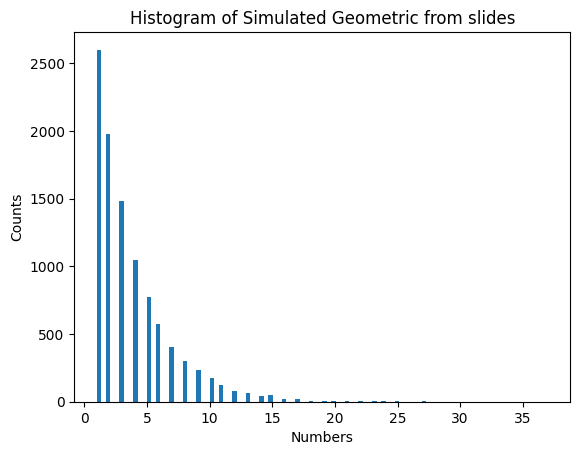

In [ ]:
import numpy as np

np.random.seed(42)
U = np.random.rand(10000) # uniform random numbers

p = [0.002, 0.13, 0.27, 0.68, 98 ]

for i in p:
cdf_5 = stats.geom.cdf(5, p)

def geometric(U):
    logU=np.log(U)
    log1p=np.log(1-p)
    X = np.floor(logU/log1p) + 1
    return X

geometric(U)

 
plt.title("Histogram of Simulated Geometric from slides")
plt.xlabel("Numbers")
plt.ylabel("Counts")
plt.hist(geometric(U),100)

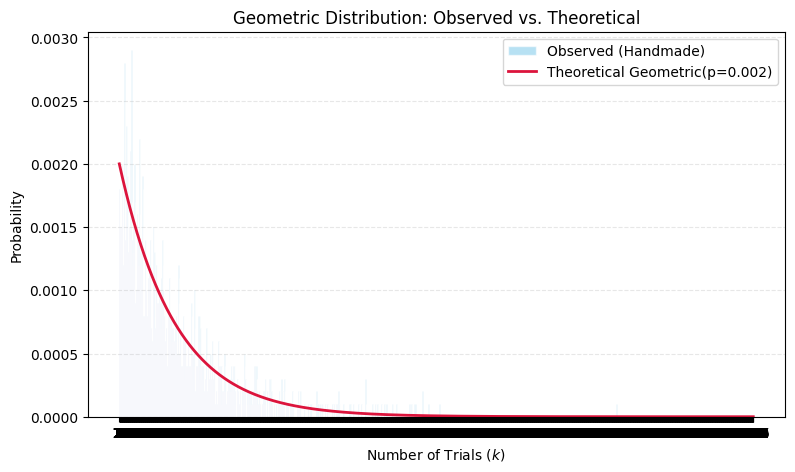

Chi-Squared p=0.002 the p-value is: 0.5574
T:1.000538876048313, Wald_wolfwiz p-value:0.3170497936724864


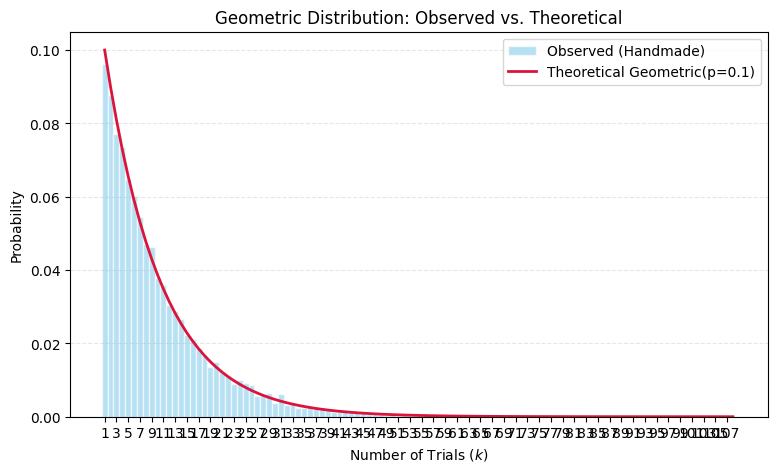

Chi-Squared p=0.1 the p-value is: 0.5412
T:0.4525990260272652, Wald_wolfwiz p-value:0.6508375002402667


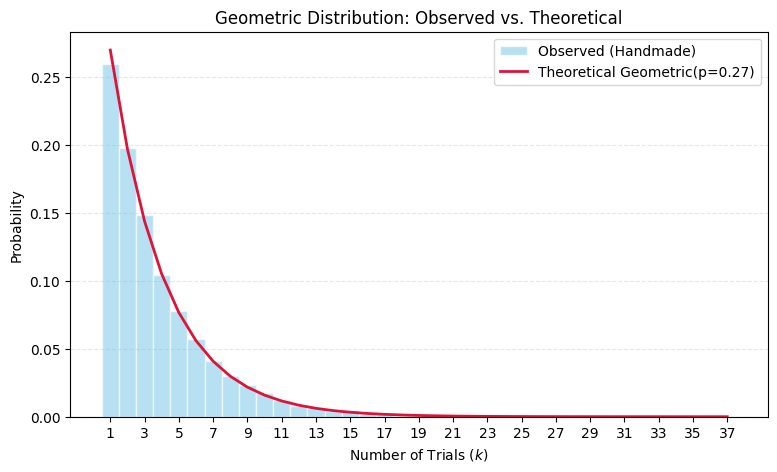

Chi-Squared p=0.27 the p-value is: 0.5572
T:0.31118586734023296, Wald_wolfwiz p-value:0.7556593262735869


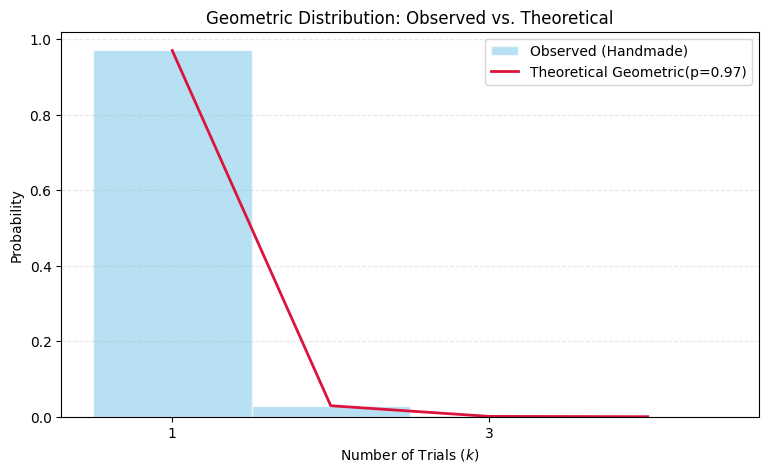

Chi-Squared p=0.97 the p-value is: 0.8179
T:nan, Wald_wolfwiz p-value:nan


In [ ]:
import matplotlib.pyplot as plt  
import numpy as np
import scipy.stats as stats  
from statsmodels.sandbox.stats.runs import runstest_1samp


np.random.seed(42)
U = np.random.rand(10000)  # uniform random numbers
p = [0.002,0.1, 0.27, 0.97]

def geometric(U, p):
    logU = np.log(U)
    log1p = np.log(1 - p)
    X = np.floor(logU / log1p) + 1
    return X


for i in p:
    #constructed geometric
    X = geometric(U, i)
    plt.figure(figsize=(9, 5))
    plt.hist(
        X,
        bins=np.arange(1, int(X.max()) + 2) - 0.5,
        density=True,
        alpha=0.6,
        color="skyblue",
        edgecolor="white",
        label="Observed (Handmade)",
    )
    # Theoretical geometric PMF line
    x = np.arange(1, int(X.max()) + 1)
    plt.plot(
        x,
        stats.geom.pmf(x, i),
        "-",
        color="crimson",
        lw=2,
        label=f"Theoretical Geometric(p={i})",
    )

    plt.title("Geometric Distribution: Observed vs. Theoretical")
    plt.xlabel("Number of Trials ($k$)")
    plt.ylabel("Probability")
    plt.xticks(np.arange(1, int(X.max()) + 1, step=2))  
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.legend()
    plt.show()

# Statistical tests
# Qhi squared test
    
    # Define bins and sample size
    X = geometric(U, i)
    bins = 10  
    N = len(X)
    # I set the range from 0.5 to 10.5 so each integer gets its own bin
    n_observed, _ = np.histogram(X, bins=bins, range=(0.5, bins + 0.5))
    n_observed[-1] = np.sum(X >= bins)


    # expected Counts using the true Geometric PMF instead of a flat line
    k_values = np.arange(1, bins + 1)
    n_expected = stats.geom.pmf(k_values, i) * N

    # Not sure if needed: but this bit is Ensuring total sum of expected matches N perfectly
    # We add any remaining tail probability (k > 10) into the last bin
    leftover_tail_prob = 1.0 - stats.geom.cdf(bins, i)
    n_expected[-1] += leftover_tail_prob * N

    chi2_stat, p_val_chi2 = stats.chisquare(f_obs=n_observed, f_exp=n_expected)
    
    #print(f"Observed counts: {n_observed}")
    #print(f"Expected counts: {n_expected}")
    print(f"Chi-Squared p={i} the p-value is: {p_val_chi2:.4f}")

# Run tests
    T, p = runstest_1samp(X, cutoff="median")
    print(f"T:{T}, Wald_wolfwiz p-value:{p}")

 

    

## Part 2

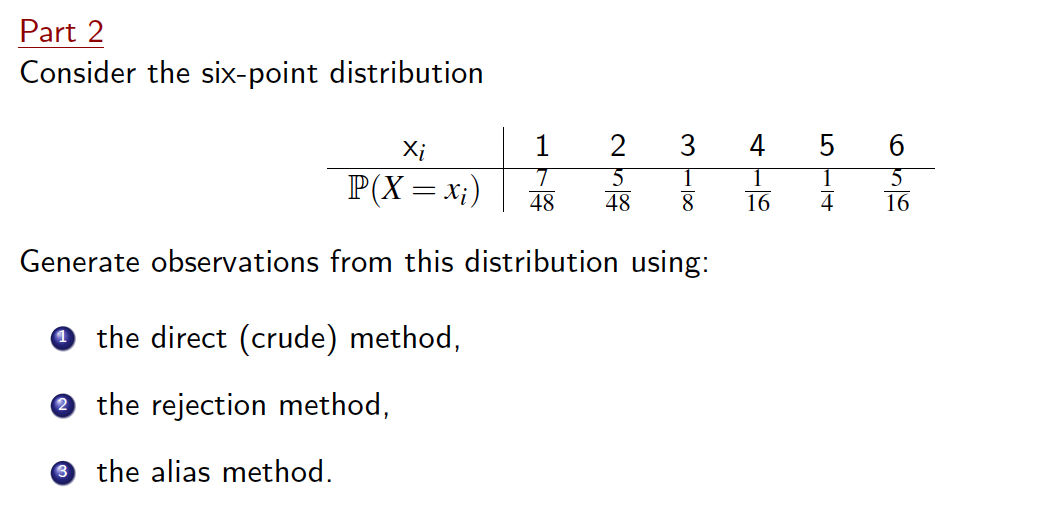

In [ ]:

np.random.seed(42)
U = np.random.rand(10000)  # uniform random numbers
x = np.array([1,2,3,4,5,6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])
n = 10000
#As it says in the slides, the value x_i is selected whenever U falls into an interval of length p_i. 
def direct_method(U,x,p):
    intervals = np.cumsum(p) # so first interval is 0 to 7/48 nexct is 7/48 to 5/48 and so on
    # search sorted creates these indexes  a[i-1] < v <= a[i] and has numpy.searchsorted(a, v, side='left', sorter=None)
    index= np.searchsorted(intervals, U, side='left', sorter=None)
    X= x[index]
    return X

print(f"The distribution using Direct: {direct_method(U, x,p)}")

def rejection_method(x,p, n):
    samples = []
    k = len(x) # k is the amount of bins to land in
    c = np.max(p)+0.001  # upper value. 

    # we continue undtil we have 10.000 accepted values
    while len(samples) < n: 
        # First we generate a number from U
        U1 = np.random.rand() #U is between 0 and 1
        I = int(np.floor(k*U1)+1) # then the proposal is U scaled so its an integer bertween 1 and 6
        #now the bin is picked

        # now selecting a point between 0 and c U<= pI/c <=> U*c = PI
        U2 = np.random.rand() #
        p_i = p[I - 1] #this is the probability is should be below
        if U2 <= p_i/c:
            samples.append(x[I-1]) # Accept

    return np.array(samples)
    
print(f"The distribution using rejection method {rejection_method(x,p,n)}")

np.random.seed(42)
def alias_tables(p, x, eps):
    k = len(x)
    L = np.arange(1, k +1) #np.arange(1, k+1, 1) # in our case its actually just x, but this is mere genereal
    F = k*p

    G = [idx for idx in range(k) if F[idx] >= 1]
    S = [idx for idx in range(k) if F[idx] < 1]

    #as long as S is not empty we do...
    while len(S) > 0:
        #a)
        j = S[0] #S(1) we remove it afterwards
        i = G[0] 
        #b) 
        L[j]= i
        F[i]= F[i] - (1-F[j])
        if F[i] < 1 - eps :
            G.pop(0)
            S.append(i)
        S.pop(0)
    return F, L
np.random.seed(42)

def alias_method(p, x, eps):
    F, L = alias_tables(p, x, eps)
    samples = []
    k = len(x) # k is the amount of bins to land in

    while len(samples) < n: 
        # First we generate a number from U
        U1 = np.random.rand() #U is between 0 and 1
        I = int(np.floor(k*U1)+1) # then the proposal is U scaled so its an integer bertween 1 and 6
        #now the bin is picked

        U2 = np.random.rand() #
        if U2 <= F[I-1]:
            samples.append(x[I-1]) # Accept
        else:
            samples.append(L[I-1])
    return np.array(samples)
    

np.random.seed(42)
alias_method(p, x, 0.01)









The distribution using Direct: [3 6 6 ... 6 4 2]
The distribution using rejection method [3 5 6 ... 5 3 3]


array([4, 5, 1, ..., 6, 1, 3], shape=(10000,))

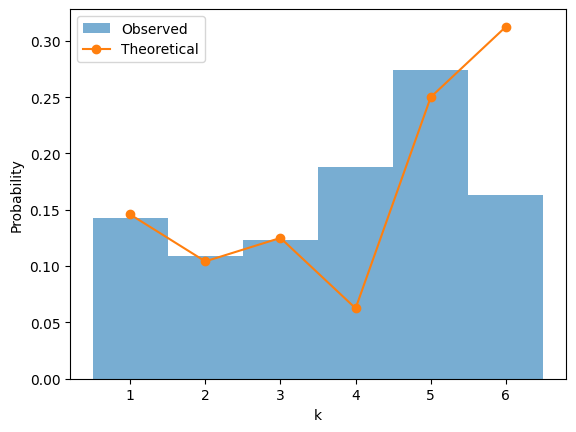

In [ ]:
# Histogram of observed data
np.random.seed(42)
X =alias_method(p, x, 0.01)
plt.hist(X,
         bins=np.arange(1, X.max() + 2) - 0.5,
         density=True,
         alpha=0.6,
         label='Observed')

# Theoretical
x = np.array([1, 2, 3, 4, 5, 6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

plt.plot(x, p, 'o-', label='Theoretical')

plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()



### Part 3 Exercises 3

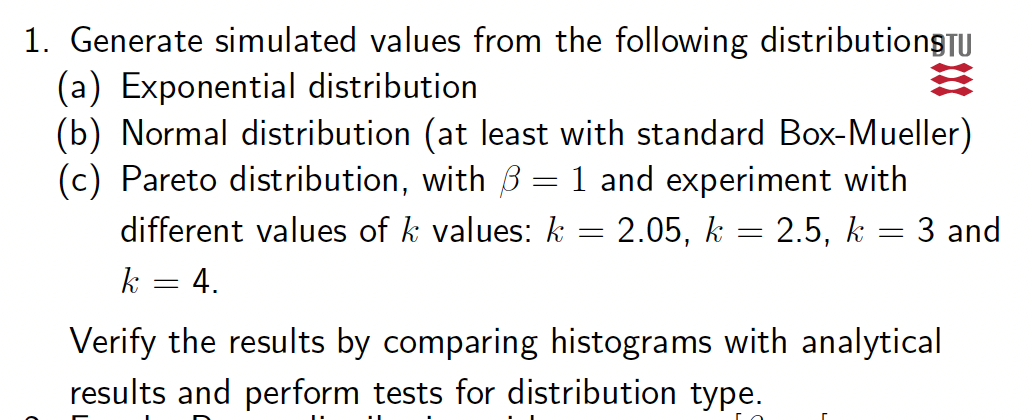

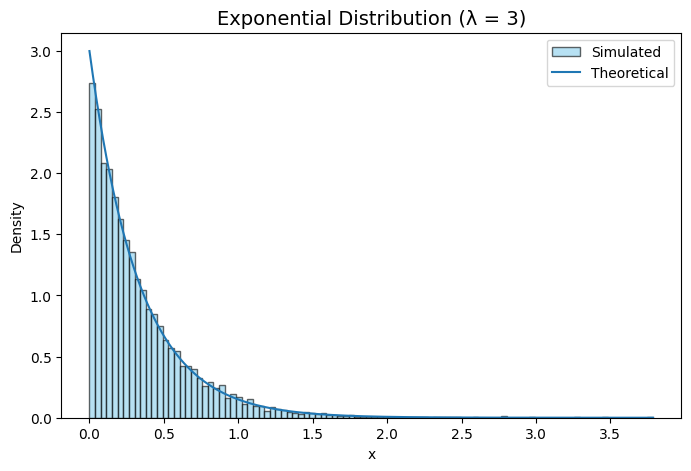

In [90]:
np.random.seed(42)
S= 10000
lamba = 3
#a) Exponential
def exp_samples(lamba, S):
    U = np.random.rand(S) 
    Y = - np.log(U)/lamba
    return Y

exp_samples = exp_samples(lamba, S)

plt.figure(figsize=(8, 5))
plt.hist(exp_samples, bins=100, density=True, alpha=0.6, color="skyblue", edgecolor="black", label="Simulated")
# Theoretical
x = np.linspace(np.min(exp_samples),np.max(exp_samples),10000)
theoretical_pdf_exp = lamba*np.exp(-lamba*x)
plt.plot(x, theoretical_pdf_exp, '-', label='Theoretical')
plt.title("Exponential Distribution (λ = 3)", fontsize=14)
plt.legend()
plt.ylabel('Density')
plt.xlabel('x')
plt.show()



In [98]:
# Bin edges (last bin extends to infinity)

from scipy.stats import chisquare, expon
bin_edges = np.array([
    0.0, 0.1, 0.2, 0.3, 0.5,
    0.8, 1.2, np.inf
])

# Observed frequencies
observed, _ = np.histogram(exp_samples, bins=bin_edges)

# Expected frequencies
cdf_vals = expon(scale=1/lamba).cdf(bin_edges)
expected = S * np.diff(cdf_vals)

# Chi-square goodness-of-fit test
chi2_stat, p_value = chisquare(
    f_obs=observed,
    f_exp=expected
)
print("Chi-square statistic:", chi2_stat)
print(f"Chi-square statistic: {chi2_stat:.3f}")
print("p-value:", p_value)
print(f"p-value: {p_value:.3f}")

Chi-square statistic: 7.844806066942353
Chi-square statistic: 7.845
p-value: 0.2496951749558816
p-value: 0.250


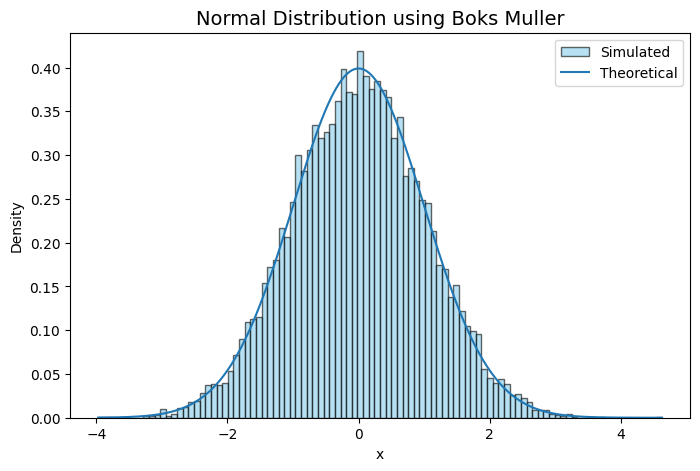

In [101]:
#b) Normal distribution using Boks Muller Method.
np.random.seed(42)
mu= 0
std= 1

def norm_samples(S, mu, std):
    U1 = np.random.rand(S) 
    U2 = np.random.rand(S) 

    Z1 = np.sqrt(-2*np.log(U1))*np.cos(2*np.pi*U2)
    Z2 = np.sqrt(-2*np.log(U1))*np.sin(2*np.pi*U2)
    return mu + std * Z1

norm_samples = norm_samples(S, mu, std)

plt.figure(figsize=(8, 5))
plt.hist(norm_samples,100,density=True, alpha=0.6, color="skyblue", edgecolor="black", label="Simulated")
# Theoretical
x = np.linspace(np.min(norm_samples),np.max(norm_samples),10000)
theoretical_pdf_exp = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x - mu) / std) ** 2
)
plt.plot(x, theoretical_pdf_exp, '-', label='Theoretical')
plt.title("Normal Distribution using Boks Muller", fontsize=14)
plt.ylabel('Density')
plt.xlabel('x')
plt.legend()
plt.show()


In [102]:
# Qhi test for the normal distribution: 

# Bin edges (last bin extends to infinity)
bin_edges = np.array([
    -np.inf, -4, -2, -1, 0, 1, 2, 4, np.inf
])

# Observed frequencies
observed, _ = np.histogram(norm_samples, bins=bin_edges)

# Expected frequencies
theoretical_cdf = stats.norm(loc=mu, scale= std).cdf(bin_edges)
expected = S * np.diff(theoretical_cdf)

# Chi-square goodness-of-fit test
chi2_stat, p_value = chisquare(
    f_obs=observed,
    f_exp=expected
)
print(f"Chi-square statistic:, {chi2_stat:.3f}")
print(f"p-value:, {p_value:.3f}")




Chi-square statistic:, 7.954
p-value:, 0.337


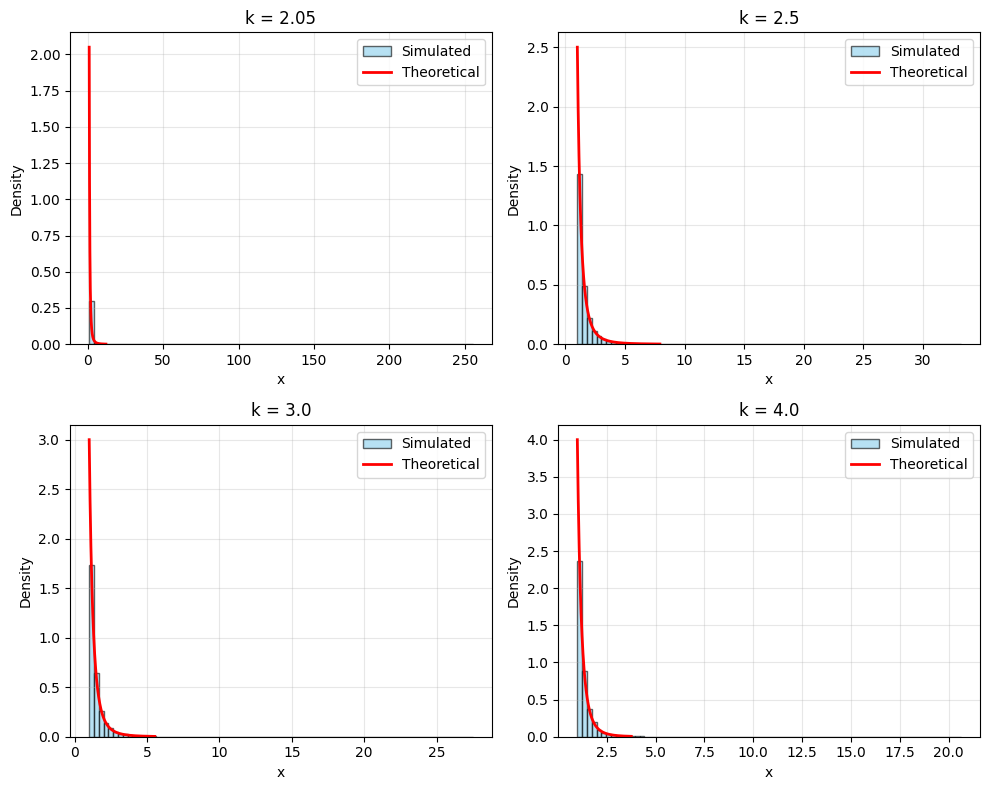

In [110]:
# ------ Pareto distribution -------
np.random.seed(42)
beta = 1
k_vals = np.array([2.05, 2.5, 3, 4])
S = 10000

def pareto(beta, k, S):
    U = np.random.rand(S)
    F = beta*U**(-1/k)
    #sample
    sample_expectation = np.mean(F)
    sample_variance = np.var(F)

    return F, sample_expectation, sample_variance


fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten() 
for i, k in enumerate(k_vals):
    F, sample_expectation, sample_variance= pareto(beta, k, S)
    ax = axes[i]
    # Histogram
    ax.hist(F, bins=80, density=True, alpha=0.6, color="skyblue", edgecolor="black", label="Simulated")
    # Theoretical PDF
    x = np.linspace(beta, np.percentile(F, 99.5), 1000)
    theoretical_pdf_pareto = k*beta**k/(x**(k+1))
    ax.plot(x, theoretical_pdf_pareto, 'r-', linewidth=2, label="Theoretical")
    ax.set_title(f"k = {k}")
    ax.set_xlabel("x")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [127]:
# ------ Pareto distribution -------
np.random.seed(42)
#exercise 3.1 c) and 3.2. 
beta = 1
k = np.array([2.05, 2.5, 3, 4])

def pareto(beta, k, S):
    U = np.random.rand(S)
    F = beta*U**(-1/k)
    #sample
    sample_expectation = np.mean(F)
    sample_variance = np.var(F)

    return F, sample_expectation, sample_variance

teoretical_expectation = k /(k-1)*beta  # for k > 1 - theoretical values
teoretical_variance =  k/((k-1)**2*(k-2))*beta**2 # for k > 2 - theoretical values
for i in range(len(k)): 
    F, sample_expectation, sample_variance = pareto(beta, k[i], S)
    # Theoretical
    theoretical_pdf_pareto = k[i]*beta**k[i]/(x**(k[i]+1))
    # Qhi test for the pareto distribution: 
    # Bin edges smallest possible value is beta and then tails to infinity. 
    bin_edges =  np.array([beta, 1.2, 1.5, 1.8, 2.2, 3.0, 5.0, np.inf])
    # Observed frequencies
    observed, _ = np.histogram(F, bins=bin_edges)
    # Expected frequencies
    theoretical_cdf = 1.0 - (beta / bin_edges) ** k[i]
    expected = S * np.diff(theoretical_cdf)
    # Chi-square goodness-of-fit test
    chi2_stat, p_value = chisquare(
        f_obs=observed,
        f_exp=expected
    )
    print(f"k:{k[i]} Chi-square statistic: {chi2_stat:.3f} p-value: {p_value:.3f}")
    print(f"Calculated expectation: { sample_expectation:.3f}")
    print(f"Theoretical expectation: {teoretical_expectation}")
    print(f"difference in expectation: {np.abs( teoretical_expectation-sample_expectation)}")
    print(f"Calculated variance: { sample_variance:.3f}")
    print(f"Theoretical variance: { teoretical_variance}")
    print(f"difference in variance: { np.abs(teoretical_variance-sample_variance)}")



k:2.05 Chi-square statistic: 7.703 p-value: 0.261
Calculated expectation: 2.000
Theoretical expectation: [1.95238095 1.66666667 1.5        1.33333333]
difference in expectation: [0.04749339 0.33320768 0.49987435 0.66654101]
Calculated variance: 15.481
Theoretical variance: [37.18820862  2.22222222  0.75        0.22222222]
difference in variance: [21.70683067 13.25915573 14.73137795 15.25915573]
k:2.5 Chi-square statistic: 2.681 p-value: 0.848
Calculated expectation: 1.652
Theoretical expectation: [1.95238095 1.66666667 1.5        1.33333333]
difference in expectation: [0.30074701 0.01503272 0.15163394 0.31830061]
Calculated variance: 1.419
Theoretical variance: [37.18820862  2.22222222  0.75        0.22222222]
difference in variance: [35.76900943  0.80302303  0.66919919  1.19697697]
k:3.0 Chi-square statistic: 4.025 p-value: 0.673
Calculated expectation: 1.495
Theoretical expectation: [1.95238095 1.66666667 1.5        1.33333333]
difference in expectation: [0.45785169 0.1721374  0.0054

Discussion of problems 

for the lower k values ( close to 2 we underestimate the variance, get a lower one calculated compared to theoretical, but it becomes less significant when k increases. ) we suspect that this oddity comes from the fraction approcing division with zero. maybe? 

all the means are pretty okay but also become better when wer aproach 2. 

In [130]:
# ------ Pareto distribution -------
np.random.seed(42)
#exercise 3.1 c) and 3.2. 
beta = 1
k = np.array([2.05, 2.5, 3, 4])

def pareto(beta, k, S):
    U = np.random.rand(S)
    F = beta*U**(-1/k)
    #sample
    sample_expectation = np.mean(F)
    sample_variance = np.var(F)

    return F, sample_expectation, sample_variance

teoretical_expectation = k /(k-1)*beta  # for k > 1 - theoretical values
teoretical_variance =  k/((k-1)**2*(k-2))*beta**2 # for k > 2 - theoretical values
print(f"Theoretical expectation: {teoretical_expectation}")
print(f"Theoretical variance: { teoretical_variance}")
for i in range(len(k)): 
    F, sample_expectation, sample_variance = pareto(beta, k[i], S)
    # Theoretical
    theoretical_pdf_pareto = k[i]*beta**k[i]/(x**(k[i]+1))
    # Qhi test for the pareto distribution: 
    # Bin edges smallest possible value is beta and then tails to infinity. 
    bin_edges =  np.array([beta, 1.2, 1.5, 1.8, 2.2, 3.0, 5.0, np.inf])
    # Observed frequencies
    observed, _ = np.histogram(F, bins=bin_edges)
    # Expected frequencies
    theoretical_cdf = 1.0 - (beta / bin_edges) ** k[i]
    expected = S * np.diff(theoretical_cdf)
    # Chi-square goodness-of-fit test
    chi2_stat, p_value = chisquare(
        f_obs=observed,
        f_exp=expected
    )
    print(f"k:{k[i]}")
    print(f"Calculated expectation: { sample_expectation:.3f}")
    print(f"difference in expectation: {np.abs( teoretical_expectation-sample_expectation)}")
    print(f"Calculated variance: { sample_variance:.3f}")
    print(f"difference in variance: { np.abs(teoretical_variance-sample_variance)}")



Theoretical expectation: [1.95238095 1.66666667 1.5        1.33333333]
Theoretical variance: [37.18820862  2.22222222  0.75        0.22222222]
k:2.05
Calculated expectation: 2.000
difference in expectation: [0.04749339 0.33320768 0.49987435 0.66654101]
Calculated variance: 15.481
difference in variance: [21.70683067 13.25915573 14.73137795 15.25915573]
k:2.5
Calculated expectation: 1.652
difference in expectation: [0.30074701 0.01503272 0.15163394 0.31830061]
Calculated variance: 1.419
difference in variance: [35.76900943  0.80302303  0.66919919  1.19697697]
k:3.0
Calculated expectation: 1.495
difference in expectation: [0.45785169 0.1721374  0.00547073 0.16119593]
Calculated variance: 0.716
difference in variance: [3.64726567e+01 1.50667027e+00 3.44480493e-02 4.93329728e-01]
k:4.0
Calculated expectation: 1.337
difference in expectation: [0.61501397 0.32929968 0.16263302 0.00403365]
Calculated variance: 0.257
difference in variance: [3.69314760e+01 1.96548965e+00 4.93267427e-01 3.45103

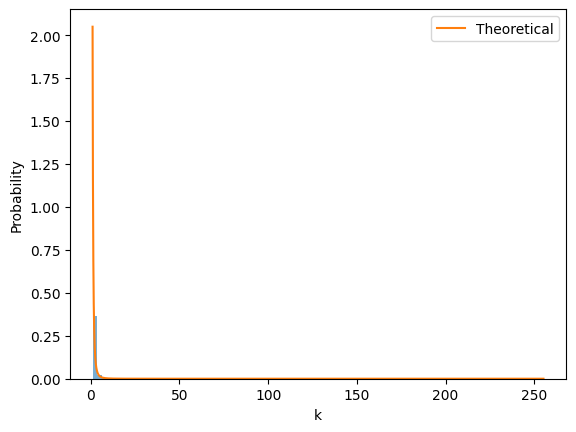

Chi-square statistic: 7.702638950406866
p-value: 0.260708140664208
Calculated expectation: 1.9998743451428789
Theoretical expectation: 1.9523809523809526
difference in expectation: 0.04749339276192632
Calculated variance: 15.481377951704149
Theoretical variance: 37.18820861678019
difference in variance: 21.70683066507604


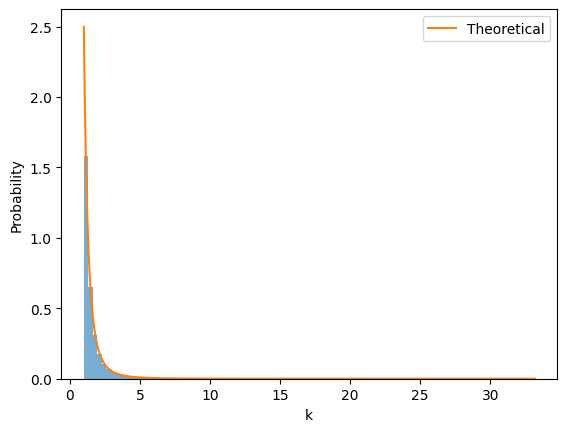

Chi-square statistic: 2.6814308576957013
p-value: 0.8476356894892558
Calculated expectation: 1.6516339420614503
Theoretical expectation: 1.6666666666666667
difference in expectation: 0.01503272460521643
Calculated variance: 1.4191991917244373
Theoretical variance: 2.2222222222222223
difference in variance: 0.803023030497785


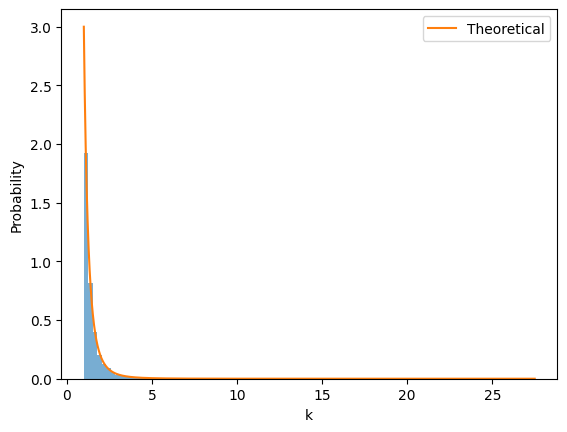

Chi-square statistic: 4.025154813570687
p-value: 0.6732721271005598
Calculated expectation: 1.4945292665012504
Theoretical expectation: 1.5
difference in expectation: 0.005470733498749603
Calculated variance: 0.7155519506587361
Theoretical variance: 0.75
difference in variance: 0.03444804934126389


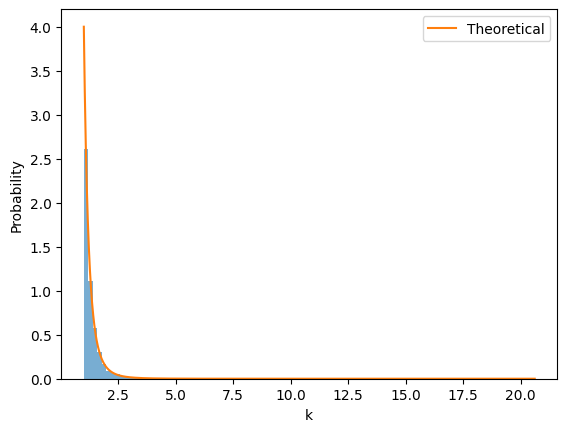

Chi-square statistic: 2.990453641795329
p-value: 0.810044044062114
Calculated expectation: 1.3373669839659401
Theoretical expectation: 1.3333333333333333
difference in expectation: 0.0040336506326068555
Calculated variance: 0.2567325729354677
Theoretical variance: 0.2222222222222222
difference in variance: 0.034510350713245486


In [131]:
# Pareto distribution 

#exercise 1 c) and 2. 
beta = 1
k = np.array([2.05, 2.5, 3, 4])

np.random.seed(42)
def pareto(beta, k, S):
    U = np.random.rand(S)
    F = beta*U**(-1/k)
    #theoretical
    expectation = k /(k-1)*beta  # for k > 1 - theoretical valuer
    variance =  k/((k-1)**2*(k-2))*beta**2 # for k > 2 - theoretical values

    #sample
    sample_expectation = np.mean(F)
    sample_variance = np.var(F)

    return F, expectation, variance, sample_expectation, sample_variance

for i in range(len(k)): 
    F, expectation, variance, sample_expectation, sample_variance = pareto(beta, k[i], S)
    plt.hist(F,100,density=True, alpha=0.6) 
    # Theoretical
    x = np.linspace(np.min(F),np.max(F),10000)
    theoretical_pdf_pareto = k[i]*beta**k[i]/(x**(k[i]+1))

    plt.plot(x, theoretical_pdf_pareto, '-', label='Theoretical')
    plt.xlabel('k')
    plt.ylabel('Probability')
    plt.legend()
    plt.show()

    # Qhi test for the pareto distribution: 
    # Bin edges smallest possible value is beta and then tails to infinity. 
    bin_edges =  np.array([beta, 1.2, 1.5, 1.8, 2.2, 3.0, 5.0, np.inf])
    # Observed frequencies
    observed, _ = np.histogram(F, bins=bin_edges)

    # Expected frequencies
    theoretical_cdf = 1.0 - (beta / bin_edges) ** k[i]
    expected = S * np.diff(theoretical_cdf)

    # Chi-square goodness-of-fit test
    chi2_stat, p_value = chisquare(
        f_obs=observed,
        f_exp=expected
    )
    print("Chi-square statistic:", chi2_stat)
    print("p-value:", p_value)
    print(f"Calculated expectation: { sample_expectation}")
    print(f"Theoretical expectation: { expectation}")
    print(f"difference in expectation: {np.abs( expectation-sample_expectation)}")

    print(f"Calculated variance: { sample_variance}")
    print(f"Theoretical variance: { variance}")
    print(f"difference in variance: { np.abs(variance-sample_variance)}")

### 3) For the normal distribution generate 100 95% confidence intervals for the mean and variance, each based on 10 observations. Discuss the results.

In [ ]:
import numpy as np
from scipy.stats import t, chi2
S=10000
mu=0
std=1
amount = 100
observations = 10

def norm_samples(S, mu, std):
    U1 = np.random.rand(S) 
    U2 = np.random.rand(S) 

    Z1 = np.sqrt(-2*np.log(U1))*np.cos(2*np.pi*U2)
    Z2 = np.sqrt(-2*np.log(U1))*np.sin(2*np.pi*U2)
    return mu + std * Z1

mu= 0
std= 1
n = 10
def norm_intervals(amount, n, mu, std): 
    mean_lower = []
    mean_upper = []
    stand_lower = []
    stand_upper = []
    # 95% confidense interval 
    for i in range(amount): 
        U= norm_samples(n, mu, std)
        mean = np.mean(U)
        stand = np.std(U, ddof=1)

        #calculate confidense interval for the mean
        CI_mean_upper = mean+t.ppf(0.975, df=n-1)*stand/np.sqrt(n)
        CI_mean_lower = mean-t.ppf(0.975, df=n-1)*stand/np.sqrt(n)
        
        mean_lower.append(CI_mean_lower)
        mean_upper.append(CI_mean_upper)

        CI_std_upper = np.sqrt((n-1)*stand**2/(chi2.ppf(0.025, n-1)))
        CI_std_lower = np.sqrt((n-1)*stand**2/(chi2.ppf(0.975, n-1)))
        
        stand_lower.append(CI_std_lower)
        stand_upper.append(CI_std_upper)
    summary_mean_lower=np.mean(mean_lower)
    summary_mean_upper=np.mean(mean_upper)
    summary_std_lower=np.mean(stand_lower)
    summary_std_upper=np.mean(stand_upper)
    print(f"Mean Lower, upper: {summary_mean_lower,summary_mean_upper},\n std lower, upper: {summary_std_lower,summary_std_upper}")

        

norm_intervals(amount, observations, mu, std)

    


Mean Lower, upper: (np.float64(-0.6922383022290477), np.float64(0.6919712544828553)),
 std lower, upper: (np.float64(0.6654776508608399), np.float64(1.7662701236142002))


So i can see that when i draw the 10 samples i get means that are like centrered around 0 but variang quite a lot, and also a stanard deviation that varies, and i dont get how the mean of the lower variance is larger than the mean of the upper. 

### 4) 

KeyboardInterrupt: 

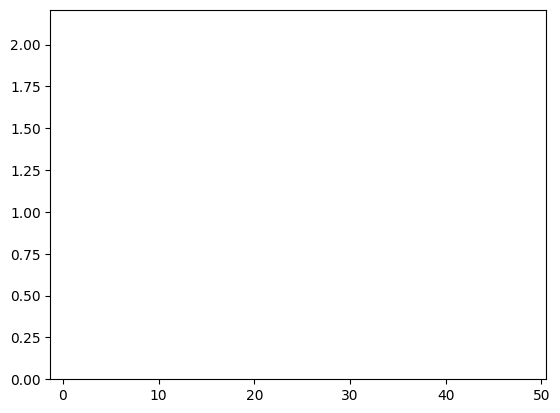

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
S = 10000
k = np.array([2.05, 2.5, 3, 4])

def pareto(beta, k, S):
    U = np.random.rand(S)
    F = beta*U**(-1/k)

    return F

def composite_distribution(k, S, beta=1):
    samples = []
    for i in range(S):
        #first we uniformely pick a k ( a model) from the k_list
        # Pick exactly one element uniformly at random
        ki = np.random.choice(k)
        #then we pick a number from the pareto distribution using that k
        F= pareto(beta, ki, 1)
        samples.append(F)

    return samples

samples = composite_distribution(k, S, beta=1)
plt.hist(samples,100,density=True, alpha=0.6) 
plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.show()

    


S

# Day 3

## Exercise 4.1

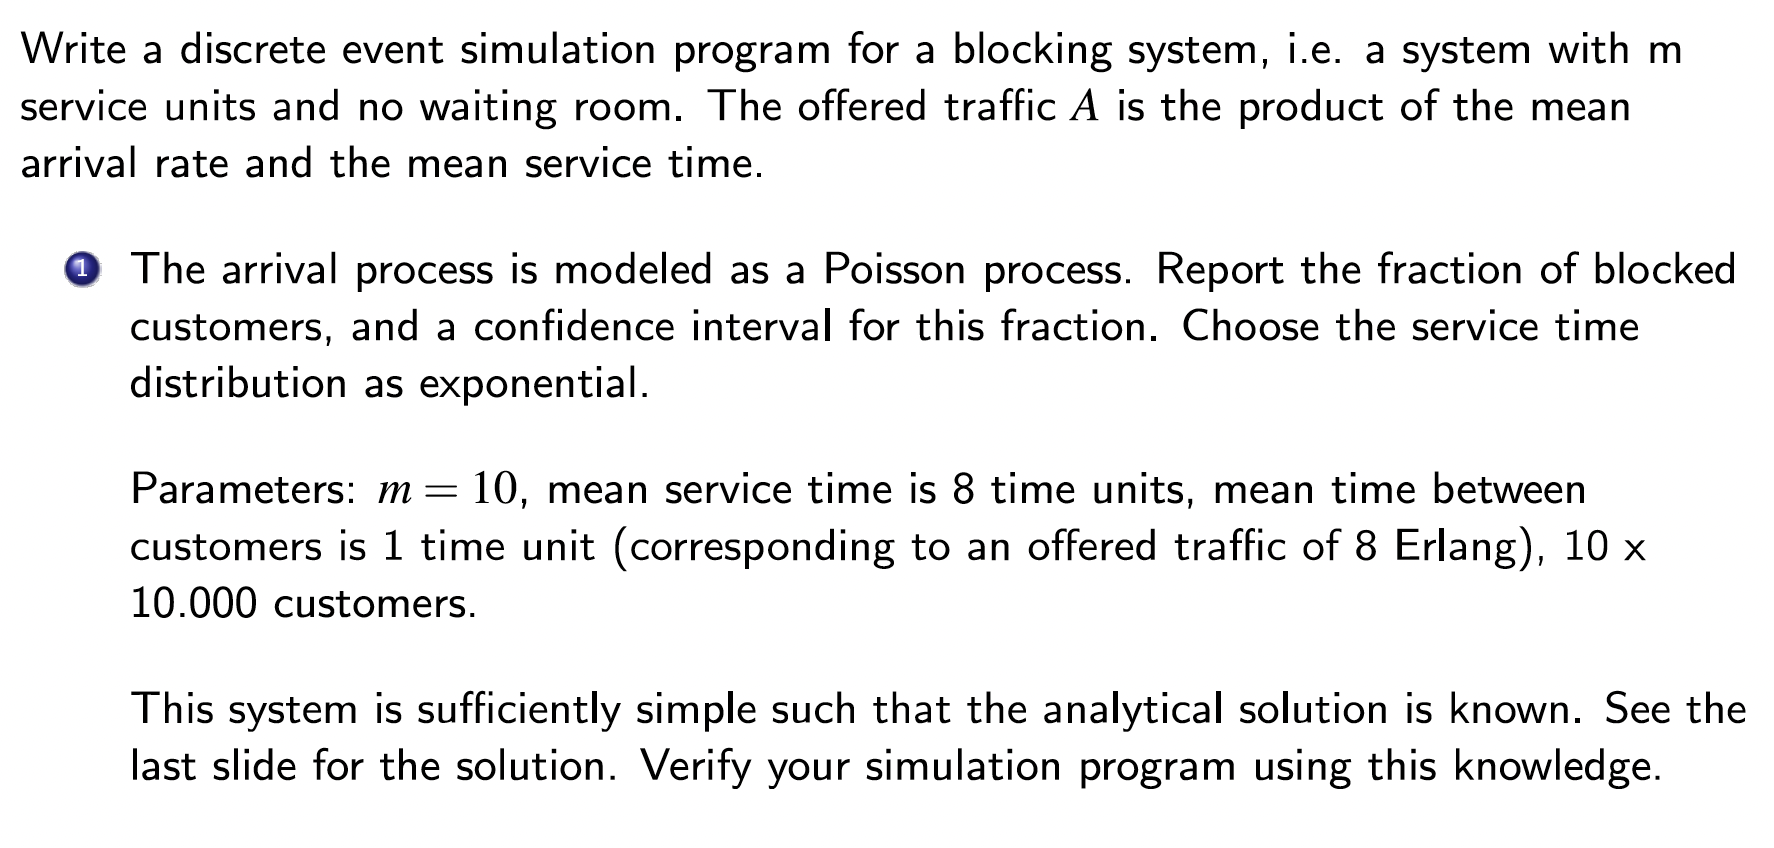

We need to write a discrete event simulation programe.

it has m service units. and no waiting room. 

Offered trafic A is the product of the mean arrival rate and the mean service time. 

The arrival process is modelled as apoisson process. 

We need to report the fraction of blocked costumers, and a confidense interval for this fraction. 

The service time distribution is exponential. 

We have Two types of events. 

Arrival:,( if there is a server available then the costumer "gets that" otherwise it is blocked.) 

Departure: A costumer is done with service and releases the server. 


We need to simulate 100.000 Costumerts, but dividede into 10 subsamples with 10.000 costumers each time. 

The thing thats smart about poisson distributions is that the time between two (following each other ) events ( interval times) is independant and exponentially distributed. 

Our arrival process is a possion process, this is the collected system seen from the outside. it counts the number of costumers that arrives in a certain time frame. ( 10 per hours e.g)

The exponential time is the time between the arrivals this is exponentially distributed, 

In [ ]:
import heapq
import numpy as np
from scipy.stats import t
import math

np.random.seed(42)
# Parameters
m = 10
mean_service_time = 8 
mean_interarrival_time = 1.0 # time between costumers
runs = 10 
customers_per_run = 10000 # 100.000/runs

#Rates for the esponential distributions, the lambdas
arrival_rate = 1/mean_interarrival_time
service_rate = 1/mean_service_time

A = arrival_rate * mean_service_time

def simulate_blocking_system(m, num_customers, arrival_rate, service_rate):
    #We run one ( out of the 10) Descrete event simulations
    #state variables
    current_time = 0.0
    active_servers = 0.0

    #statistical quantities
    blocked_customers = 0
    total_customers = 0 

    # Event List
    event_list = []
    #the waiting time from starting to the first costumer arrives follows and exponential distribution
    #current time = 0 in the first arrival case.
    first_arrival = current_time + np.random.exponential(1/arrival_rate)
    #we add the event that the first costumer has arrived to the event list ( time, event)
    heapq.heappush(event_list, (first_arrival, "arrival"))
    # we use heapq in order to make sure we keep the time kronologically, heapq 
    #retrives the tuple from the qeue with the lowest time. 

    # while not all 10.000 customers has arrived. 
    while total_customers < num_customers:
        #in this simpel example this never happens ( the store is open untill all costumers has arrived, but in real life we might have that the store closes and the eventlist is therfore empty).
        if not event_list:
            break

        #We jumpt to ( and exstract) the next event in time. 
        event_time, event_type = heapq.heappop(event_list)
        current_time = event_time

        if event_type == "arrival":
            #next thing that happens in time is that a costumer arrives
            total_customers += 1

            #if the amount of active servers is less than the amount of servers, we have available servers
            if active_servers < m:
                #so the costumer imdeiatly gets service
                active_servers += 1
                # The service distribution time is exponential so it takes expoentially distributed time to give service to a costumer
                departure_time = current_time + np.random.exponential(1/service_rate)
                #we add the event to the event list
                heapq.heappush(event_list, (departure_time, "departure"))
            else: 
                #there are no available servers so we block the costumer
                blocked_customers += 1

            # we now plan for the next costumer arrival ( we dont knwo if this is gonna be before doing or after the first/current costumer gets service.)
            next_arrival_time = current_time + np.random.exponential(1/arrival_rate)
            heapq.heappush(event_list, (next_arrival_time, "arrival"))

        elif event_type == "departure":
            #costumers leaves the systems therefore vacading a server
            active_servers -= 1

    #we are asked to report the blocking fraction
    return blocked_customers / total_customers

blocking_fractions = []

for run in range(runs):
    fraction = simulate_blocking_system(m, customers_per_run, arrival_rate, service_rate)
    blocking_fractions.append(fraction) 

#Statisical Tests and confidense intervals

mean_blocked = np.mean(blocking_fractions)
std_blocked = np.std(blocking_fractions, ddof = 1)
standard_error = std_blocked / np.sqrt(runs)

alpha = 0.05
df = runs -1
t_crit = t.ppf(1 - alpha / 2, df)

ci_lower = mean_blocked - t_crit *standard_error
ci_upper = mean_blocked + t_crit * standard_error

ci_lower, ci_upper


def Erlang_B_formula(m, A):
    t = A**m/math.factorial(m)
    n = 0 
    for i in range(m+1): 
        n += A**i/math.factorial(i)
    return t/n

print("Exponential arrival time DES Simulation Results")
print(f"Simulated mean blocking: {mean_blocked:.5f}")
print(f"95% CI): [{ci_lower:.5f}, {ci_upper:.5f}]")
print(f"Erlang-B teoretical: {Erlang_B_formula(m, A):.5f}")

#yay the teoretical lies within the CI interval

Exponential arrival time DES Simulation Results
Simulated mean blocking: 0.11842
95% CI): [0.11411, 0.12273]
Erlang-B teoretical: 0.12166


In [ ]:
#--------This is an implementation closer to what necolai explained that dosent use heapques also more compact.

np.random.seed(42)


def controle_variates_discrete_system(m, ms, ma, n):

    blocked_customers = 0
    process = np.zeros(m)

    t = 0.0

    for _ in range(n):

        # arrival
        t += np.random.exponential(ma)

        # Set process free after their time
        process[process <= t] = 0

        # Find free process
        idle_process = np.where(process == 0)[0]

        if len(idle_process) > 0:
            process_id = idle_process[0]
            service_time = np.random.exponential(ms)
            process[process_id] = t + service_time

        else:
            blocked_customers += 1

    return blocked_customers / n



## Exercise 4.2

In [ ]:
# Now the arrival process is modelled as a renewal process 
# A) Experiment with Erlang distributed inter arrival times The Erlang distribution should have a mean of 1 time unity. 

import heapq
import numpy as np
from scipy.stats import t
import math

np.random.seed(42)
# Parameters
m = 10
mean_service_time = 8 

mean_interarrival_time =  1.0 # time between costumers

runs = 10 
customers_per_run = 10000 # 100.000/runs

#Rates for the esponential distributions, the lambdas

arrival_rate = 1 # Nu er det bare 1  #_________
k = 2
service_rate = 1/mean_service_time

A = arrival_rate * mean_service_time


def Erlang_dist(arrival_rate, k):
    return np.random.gamma(shape=k, scale=arrival_rate/k)


def simulate_blocking_system_erlang(m, num_customers, arrival_rate, service_rate, n):
    current_time = 0.0
    active_servers = 0.0

    blocked_customers = 0
    total_customers = 0 

    event_list = []

    first_arrival = current_time + Erlang_dist(arrival_rate, k)

    heapq.heappush(event_list, (first_arrival, "arrival"))


    while total_customers < num_customers:
        #in this simpel example this never happens ( the store is open untill all costumers has arrived, but in real life we might have that the store closes and the eventlist is therfore empty).
        if not event_list:
            break

        #We jumpt to ( and exstract) the next event in time. 
        event_time, event_type = heapq.heappop(event_list)
        current_time = event_time

        if event_type == "arrival":
            #next thing that happens in time is that a costumer arrives
            total_customers += 1

            #if the amount of active servers is less than the amount of servers, we have available servers
            if active_servers < m:
                #so the costumer imdeiatly gets service
                active_servers += 1
                # The service distribution time is exponential so it takes expoentially distributed time to give service to a costumer
                departure_time = current_time + np.random.exponential(1/service_rate)
                #we add the event to the event list
                heapq.heappush(event_list, (departure_time, "departure"))
            else: 
                #there are no available servers so we block the costumer
                blocked_customers += 1

            # we now plan for the next costumer arrival ( we dont knwo if this is gonna be before doing or after the first/current costumer gets service.)
            next_arrival_time = current_time + Erlang_dist(arrival_rate, k)
            heapq.heappush(event_list, (next_arrival_time, "arrival"))

        elif event_type == "departure":
            #costumers leaves the systems therefore vacading a server
            active_servers -= 1

    #we are asked to report the blocking fraction
    return blocked_customers / total_customers

blocking_fractions = []

for run in range(runs):
    fraction = simulate_blocking_system_erlang(m, customers_per_run, arrival_rate, service_rate, n)
    blocking_fractions.append(fraction) 

#Statisical Tests and confidense intervals

mean_blocked = np.mean(blocking_fractions)
std_blocked = np.std(blocking_fractions, ddof = 1)
standard_error = std_blocked / np.sqrt(runs)

alpha = 0.05
df = runs -1
t_crit = t.ppf(1 - alpha / 2, df)

ci_lower = mean_blocked - t_crit *standard_error
ci_upper = mean_blocked + t_crit * standard_error

ci_lower, ci_upper

print("Erlang DES Simulation Results")
print(f"Simulated mean blocking: {mean_blocked:.5f}")
print(f"95% CI): [{ci_lower:.5f}, {ci_upper:.5f}]")



Erlang DES Simulation Results
Simulated mean blocking: 0.09457
95% CI): [0.09240, 0.09674]


In [ ]:
# b) Now its Hyperexponential 

# Now the arrival process is modelled as a renewal process 
# A) Experiment with Erlang distributed inter arrival times The Erlang distribution should have a mean of 1 time unity. 

import heapq
import numpy as np
from scipy.stats import t
import math

np.random.seed(42)
# Parameters
m = 10
mean_service_time = 8 

mean_interarrival_time =  1.0 # time between costumers

runs = 10 
customers_per_run = 10000 # 100.000/runs

### Hyper exponential distribution
p1 = 0.8
lamba1 = 0.83333
p2 = 0.2
lamba2 = 5.0

arrival_rate = 1 # Nu er det bare 1  #_________
k = 2
service_rate = 1/mean_service_time

A = arrival_rate * mean_service_time


def hyper_exponential(p1, lamba1, lamba2):
    u = np.random.rand()
    
    if u < p1:
        return np.random.exponential(1/lamba1)
    else:
        return np.random.exponential(1/lamba2)
    

def simulate_blocking_system_hyperexp(m, num_customers, service_rate, p1, lamba1, lamba2):
    current_time = 0.0
    active_servers = 0.0

    blocked_customers = 0
    total_customers = 0 

    event_list = []

    first_arrival = current_time + hyper_exponential(p1, lamba1, lamba2)

    heapq.heappush(event_list, (first_arrival, "arrival"))


    while total_customers < num_customers:
        #in this simpel example this never happens ( the store is open untill all costumers has arrived, but in real life we might have that the store closes and the eventlist is therfore empty).
        if not event_list:
            break

        #We jumpt to ( and exstract) the next event in time. 
        event_time, event_type = heapq.heappop(event_list)
        current_time = event_time

        if event_type == "arrival":
         
           #next thing that happens in time is that a costumer arrives
            total_customers += 1

            #if the amount of active servers is less than the amount of servers, we have available servers
            if active_servers < m:
                #so the costumer imdeiatly gets service
                active_servers += 1
                # The service distribution time is exponential so it takes expoentially distributed time to give service to a costumer
                departure_time = current_time + np.random.exponential(1/service_rate)
                #we add the event to the event list
                heapq.heappush(event_list, (departure_time, "departure"))
            else: 
                #there are no available servers so we block the costumer
                blocked_customers += 1

            # we now plan for the next costumer arrival ( we dont knwo if this is gonna be before doing or after the first/current costumer gets service.)
            next_arrival_time = current_time + hyper_exponential(p1, lamba1, lamba2)
            heapq.heappush(event_list, (next_arrival_time, "arrival"))

        elif event_type == "departure":
            #costumers leaves the systems therefore vacading a server
            active_servers -= 1

    #we are asked to report the blocking fraction
    return blocked_customers / total_customers

blocking_fractions = []

for run in range(runs):
    fraction = simulate_blocking_system_hyperexp(m, customers_per_run , service_rate, p1, lamba1, lamba2)
    blocking_fractions.append(fraction) 

#Statisical Tests and confidense intervals

mean_blocked = np.mean(blocking_fractions)
std_blocked = np.std(blocking_fractions, ddof = 1)
standard_error = std_blocked / np.sqrt(runs)

alpha = 0.05
df = runs -1
t_crit = t.ppf(1 - alpha / 2, df)

ci_lower = mean_blocked - t_crit *standard_error
ci_upper = mean_blocked + t_crit * standard_error

ci_lower, ci_upper

print("Hyper exponential DES Simulation Results")
print(f"Simulated mean blocking: {mean_blocked:.5f}")
print(f"95% CI): [{ci_lower:.5f}, {ci_upper:.5f}]")



Hyper exponential DES Simulation Results
Simulated mean blocking: 0.13887
95% CI): [0.13485, 0.14289]


## Exercise 4.3

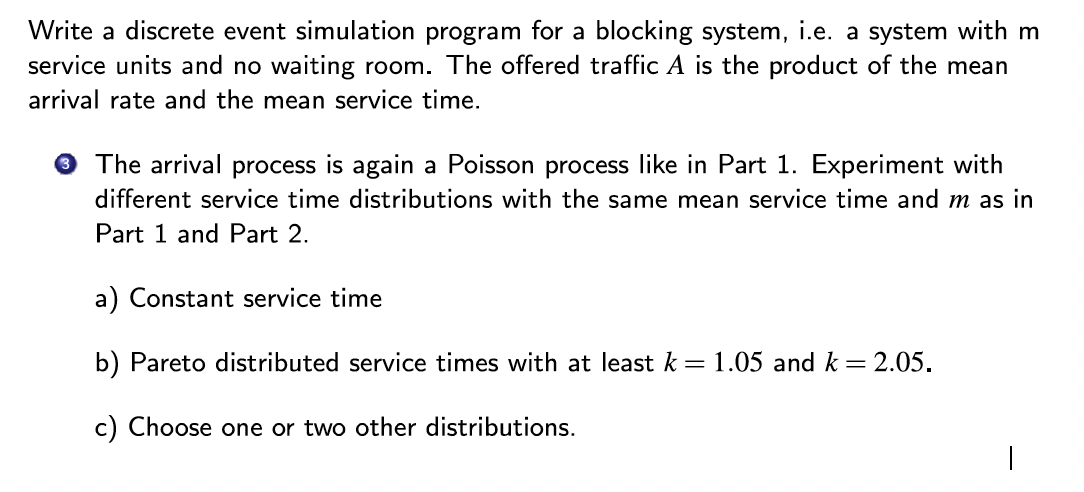

In [ ]:
import heapq
import numpy as np
from scipy.stats import t
import math

# -------- a) Constant service time ----------
np.random.seed(42)
# Parameters
m = 10
mean_service_time = 8 
mean_interarrival_time = 1.0 # time between costumers
runs = 10 
customers_per_run = 10000 # 100.000/runs

#Rates for the esponential distributions, the lambdas
arrival_rate = 1/mean_interarrival_time
service_rate = mean_service_time

A = arrival_rate * mean_service_time

def simulate_blocking_system_const_service(m, num_customers, arrival_rate, mean_service_time):
    #We run one ( out of the 10) Descrete event simulations
    #state variables
    current_time = 0.0
    active_servers = 0.0

    #statistical quantities
    blocked_customers = 0
    total_customers = 0 

    # Event List
    event_list = []
    #the waiting time from starting to the first costumer arrives follows and exponential distribution
    #current time = 0 in the first arrival case.
    first_arrival = current_time + np.random.exponential(1/arrival_rate)
    #we add the event that the first costumer has arrived to the event list ( time, event)
    heapq.heappush(event_list, (first_arrival, "arrival"))
    # we use heapq in order to make sure we keep the time kronologically, heapq 
    #retrives the tuple from the qeue with the lowest time. 

    # while not all 10.000 customers has arrived. 
    while total_customers < num_customers:
        #in this simpel example this never happens ( the store is open untill all costumers has arrived, but in real life we might have that the store closes and the eventlist is therfore empty).
        if not event_list:
            break

        #We jumpt to ( and exstract) the next event in time. 
        event_time, event_type = heapq.heappop(event_list)
        current_time = event_time

        if event_type == "arrival":
            #next thing that happens in time is that a costumer arrives
            total_customers += 1

            #if the amount of active servers is less than the amount of servers, we have available servers
            if active_servers < m:
                #so the costumer imdeiatly gets service
                active_servers += 1
                # The service distribution time is exponential so it takes expoentially distributed time to give service to a costumer
                departure_time = current_time + mean_service_time
                #we add the event to the event list
                heapq.heappush(event_list, (departure_time, "departure"))
            else: 
                #there are no available servers so we block the costumer
                blocked_customers += 1

            # we now plan for the next costumer arrival ( we dont knwo if this is gonna be before doing or after the first/current costumer gets service.)
            next_arrival_time = current_time + np.random.exponential(1/arrival_rate)
            heapq.heappush(event_list, (next_arrival_time, "arrival"))

        elif event_type == "departure":
            #costumers leaves the systems therefore vacading a server
            active_servers -= 1

    #we are asked to report the blocking fraction
    return blocked_customers / total_customers

blocking_fractions = []

for run in range(runs):
    fraction = simulate_blocking_system_const_service(m, customers_per_run, arrival_rate, mean_service_time)
    blocking_fractions.append(fraction) 

#Statisical Tests and confidense intervals

mean_blocked = np.mean(blocking_fractions)
std_blocked = np.std(blocking_fractions, ddof = 1)
standard_error = std_blocked / np.sqrt(runs)

alpha = 0.05
df = runs -1
t_crit = t.ppf(1 - alpha / 2, df)

ci_lower = mean_blocked - t_crit *standard_error
ci_upper = mean_blocked + t_crit * standard_error

ci_lower, ci_upper

print("Constant service time DES Simulation Results")
print(f"Simulated mean blocking: {mean_blocked:.5f}")
print(f"95% CI): [{ci_lower:.5f}, {ci_upper:.5f}]")


Constant service time DES Simulation Results
Simulated mean blocking: 0.12248
95% CI): [0.11826, 0.12670]


In [ ]:
##  b) ------- Pareto distributed service time 
np.random.seed(42)
import heapq
import numpy as np
from scipy.stats import t
import math

# Parameters
m = 10
mean_service_time = 8 
mean_interarrival_time = 1.0 # time between costumers
runs = 10 
customers_per_run = 10000 # 100.000/runs

#Rates for the esponential distributions, the lambdas
arrival_rate = 1/mean_interarrival_time
service_rate = 1/ mean_service_time


def pareto(beta, k):
    U = np.random.rand()
    return beta * U**(-1/k)


def simulate_blocking_system_Pareto_service_time(m, num_customers, arrival_rate, beta, k):
    #We run one ( out of the 10) Descrete event simulations
    #state variables
    current_time = 0.0
    active_servers = 0.0

    #statistical quantities
    blocked_customers = 0
    total_customers = 0 

    # Event List
    event_list = []
    #the waiting time from starting to the first costumer arrives follows and exponential distribution
    #current time = 0 in the first arrival case.
    first_arrival = current_time + np.random.exponential(1/arrival_rate)
    #we add the event that the first costumer has arrived to the event list ( time, event)
    heapq.heappush(event_list, (first_arrival, "arrival"))
    # we use heapq in order to make sure we keep the time kronologically, heapq 
    #retrives the tuple from the qeue with the lowest time. 

    # while not all 10.000 customers has arrived. 
    while total_customers < num_customers:
        #in this simpel example this never happens ( the store is open untill all costumers has arrived, but in real life we might have that the store closes and the eventlist is therfore empty).
        if not event_list:
            break

        #We jumpt to ( and exstract) the next event in time. 
        event_time, event_type = heapq.heappop(event_list)
        current_time = event_time

        if event_type == "arrival":
            #next thing that happens in time is that a costumer arrives
            total_customers += 1

            #if the amount of active servers is less than the amount of servers, we have available servers
            if active_servers < m:
                #so the costumer imdeiatly gets service
                active_servers += 1
                # The service distribution time is exponential so it takes expoentially distributed time to give service to a costumer
                departure_time = current_time + pareto(beta, k)
                #we add the event to the event list
                heapq.heappush(event_list, (departure_time, "departure"))
            else: 
                #there are no available servers so we block the costumer
                blocked_customers += 1

            # we now plan for the next costumer arrival ( we dont knwo if this is gonna be before doing or after the first/current costumer gets service.)
            next_arrival_time = current_time + np.random.exponential(1/arrival_rate)
            heapq.heappush(event_list, (next_arrival_time, "arrival"))

        elif event_type == "departure":
            #costumers leaves the systems therefore vacading a server
            active_servers -= 1

    #we are asked to report the blocking fraction
    return blocked_customers / total_customers

blocking_fractions1 = []

k = np.array([1.05, 2.05])
S = 1
for run in range(runs):
    beta = mean_service_time*(k[0]-1)/k[0]
    fraction = simulate_blocking_system_Pareto_service_time(m, customers_per_run, arrival_rate, beta, k[0])
    blocking_fractions1.append(fraction) 
#Statisical Tests and confidense intervals

mean_blocked = np.mean(blocking_fractions1)
std_blocked = np.std(blocking_fractions1, ddof = 1)
standard_error = std_blocked / np.sqrt(runs)

alpha = 0.05
df = runs -1
t_crit = t.ppf(1 - alpha / 2, df)

ci_lower = mean_blocked - t_crit *standard_error
ci_upper = mean_blocked + t_crit * standard_error

ci_lower, ci_upper

print("Constant service time DES Simulation Results")
print(f"Simulated mean blocking: {mean_blocked:.5f}")
print(f"95% CI): [{ci_lower:.5f}, {ci_upper:.5f}]")

blocking_fractions2 = []

for run in range(runs):
    beta = mean_service_time*(k[1]-1)/k[1]
    fraction = simulate_blocking_system_Pareto_service_time(m, customers_per_run, arrival_rate, beta, k[1])
    blocking_fractions2.append(fraction) 
#Statisical Tests and confidense intervals

mean_blocked = np.mean(blocking_fractions2)
std_blocked = np.std(blocking_fractions2, ddof = 1)
standard_error = std_blocked / np.sqrt(runs)

alpha = 0.05
df = runs -1
t_crit = t.ppf(1 - alpha / 2, df)

ci_lower = mean_blocked - t_crit *standard_error
ci_upper = mean_blocked + t_crit * standard_error

ci_lower, ci_upper

print("Constant service time DES Simulation Results")
print(f"Simulated mean blocking: {mean_blocked:.5f}")
print(f"95% CI): [{ci_lower:.5f}, {ci_upper:.5f}]")





Constant service time DES Simulation Results
Simulated mean blocking: 0.00107
95% CI): [0.00049, 0.00165]
Constant service time DES Simulation Results
Simulated mean blocking: 0.12124
95% CI): [0.11815, 0.12433]


In [ ]:
#####---------Choose one or two other distributions
import heapq
import numpy as np
from scipy.stats import t
import math
np.random.seed(42)
#Normal Distribution

# Parameters
m = 10
mean_service_time = 8 
mean_interarrival_time = 1.0 # time between costumers
runs = 10 
customers_per_run = 10000 # 100.000/runs
#Rates for the esponential distributions, the lambdas
arrival_rate = 1/mean_interarrival_time

#-----Normal Distribution - use mean as mean service time 
mu = mean_service_time
std = 1 # just picked this because its standard.

def simulate_blocking_system_normal(m, num_customers, arrival_rate, mu, std):
    #We run one ( out of the 10) Descrete event simulations
    #state variables
    current_time = 0.0
    active_servers = 0.0

    #statistical quantities
    blocked_customers = 0
    total_customers = 0 

    # Event List
    event_list = []
    #the waiting time from starting to the first costumer arrives follows and exponential distribution
    #current time = 0 in the first arrival case.
    first_arrival = current_time + np.random.exponential(1/arrival_rate)
    #we add the event that the first costumer has arrived to the event list ( time, event)
    heapq.heappush(event_list, (first_arrival, "arrival"))
    # we use heapq in order to make sure we keep the time kronologically, heapq 
    #retrives the tuple from the qeue with the lowest time. 

    # while not all 10.000 customers has arrived. 
    while total_customers < num_customers:
        #in this simpel example this never happens ( the store is open untill all costumers has arrived, but in real life we might have that the store closes and the eventlist is therfore empty).
        if not event_list:
            break

        #We jumpt to ( and exstract) the next event in time. 
        event_time, event_type = heapq.heappop(event_list)
        current_time = event_time

        if event_type == "arrival":
            #next thing that happens in time is that a costumer arrives
            total_customers += 1

            #if the amount of active servers is less than the amount of servers, we have available servers
            if active_servers < m:
                #so the costumer imdeiatly gets service
                active_servers += 1
                # The service distribution time is exponential so it takes expoentially distributed time to give service to a costumer
                departure_time = current_time + mu+np.random.normal()*std
                #we add the event to the event list
                heapq.heappush(event_list, (departure_time, "departure"))
            else: 
                #there are no available servers so we block the costumer
                blocked_customers += 1

            # we now plan for the next costumer arrival ( we dont knwo if this is gonna be before doing or after the first/current costumer gets service.)
            next_arrival_time = current_time + np.random.exponential(1/arrival_rate)
            heapq.heappush(event_list, (next_arrival_time, "arrival"))

        elif event_type == "departure":
            #costumers leaves the systems therefore vacading a server
            active_servers -= 1

    #we are asked to report the blocking fraction
    return blocked_customers / total_customers

blocking_fractions = []

for run in range(runs):
    fraction = simulate_blocking_system_normal(m, customers_per_run, arrival_rate, mu, std)
    blocking_fractions.append(fraction) 

#Statisical Tests and confidense intervals
mean_blocked = np.mean(blocking_fractions)
std_blocked = np.std(blocking_fractions, ddof = 1)
standard_error = std_blocked / np.sqrt(runs)

alpha = 0.05
df = runs -1
t_crit = t.ppf(1 - alpha / 2, df)

ci_lower = mean_blocked - t_crit *standard_error
ci_upper = mean_blocked + t_crit * standard_error

ci_lower, ci_upper

print("Normal distributed service time DES Simulation Results")
print(f"Simulated mean blocking: {mean_blocked:.5f}")
print(f"95% CI): [{ci_lower:.5f}, {ci_upper:.5f}]")




Normal distributed service time DES Simulation Results
Simulated mean blocking: 0.12031
95% CI): [0.11660, 0.12402]


In [ ]:
#####---------Choose one or two other distributions
import heapq
import numpy as np
from scipy.stats import t
import math

#Uniform Distribution
np.random.seed(42)
# Parameters
m = 10
mean_service_time = 8 
mean_interarrival_time = 1.0 # time between costumers
runs = 10 
customers_per_run = 10000 # 100.000/runs
#Rates for the esponential distributions, the lambdas
arrival_rate = 1/mean_interarrival_time


def simulate_blocking_system_uni(m, num_customers, arrival_rate, mean_service_time ):
    #We run one ( out of the 10) Descrete event simulations
    #state variables
    current_time = 0.0
    active_servers = 0.0

    #statistical quantities
    blocked_customers = 0
    total_customers = 0 

    # Event List
    event_list = []
    #the waiting time from starting to the first costumer arrives follows and exponential distribution
    #current time = 0 in the first arrival case.
    first_arrival = current_time + np.random.exponential(1/arrival_rate)
    #we add the event that the first costumer has arrived to the event list ( time, event)
    heapq.heappush(event_list, (first_arrival, "arrival"))
    # we use heapq in order to make sure we keep the time kronologically, heapq 
    #retrives the tuple from the qeue with the lowest time. 

    # while not all 10.000 customers has arrived. 
    while total_customers < num_customers:
        #in this simpel example this never happens ( the store is open untill all costumers has arrived, but in real life we might have that the store closes and the eventlist is therfore empty).
        if not event_list:
            break

        #We jumpt to ( and exstract) the next event in time. 
        event_time, event_type = heapq.heappop(event_list)
        current_time = event_time

        if event_type == "arrival":
            #next thing that happens in time is that a costumer arrives
            total_customers += 1

            #if the amount of active servers is less than the amount of servers, we have available servers
            if active_servers < m:
                #so the costumer imdeiatly gets service
                active_servers += 1
                # The service distribution time is exponential so it takes expoentially distributed time to give service to a costumer
                departure_time = current_time + np.random.uniform(0, 2*mean_service_time )
                #we add the event to the event list
                heapq.heappush(event_list, (departure_time, "departure"))
            else: 
                #there are no available servers so we block the costumer
                blocked_customers += 1

            # we now plan for the next costumer arrival ( we dont knwo if this is gonna be before doing or after the first/current costumer gets service.)
            next_arrival_time = current_time + np.random.exponential(1/arrival_rate)
            heapq.heappush(event_list, (next_arrival_time, "arrival"))

        elif event_type == "departure":
            #costumers leaves the systems therefore vacading a server
            active_servers -= 1

    #we are asked to report the blocking fraction
    return blocked_customers / total_customers

blocking_fractions = []

for run in range(runs):
    fraction = simulate_blocking_system_uni(m, customers_per_run, arrival_rate, mean_service_time )
    blocking_fractions.append(fraction) 

#Statisical Tests and confidense intervals
mean_blocked = np.mean(blocking_fractions)
std_blocked = np.std(blocking_fractions, ddof = 1)
standard_error = std_blocked / np.sqrt(runs)

alpha = 0.05
df = runs -1
t_crit = t.ppf(1 - alpha / 2, df)

ci_lower = mean_blocked - t_crit *standard_error
ci_upper = mean_blocked + t_crit * standard_error

ci_lower, ci_upper

print("Uniform distributed service time DES Simulation Results")
print(f"Simulated mean blocking: {mean_blocked:.5f}")
print(f"95% CI): [{ci_lower:.5f}, {ci_upper:.5f}]")




Uniform distributed service time DES Simulation Results
Simulated mean blocking: 0.12275
95% CI): [0.11894, 0.12656]


## Exercise 4.4

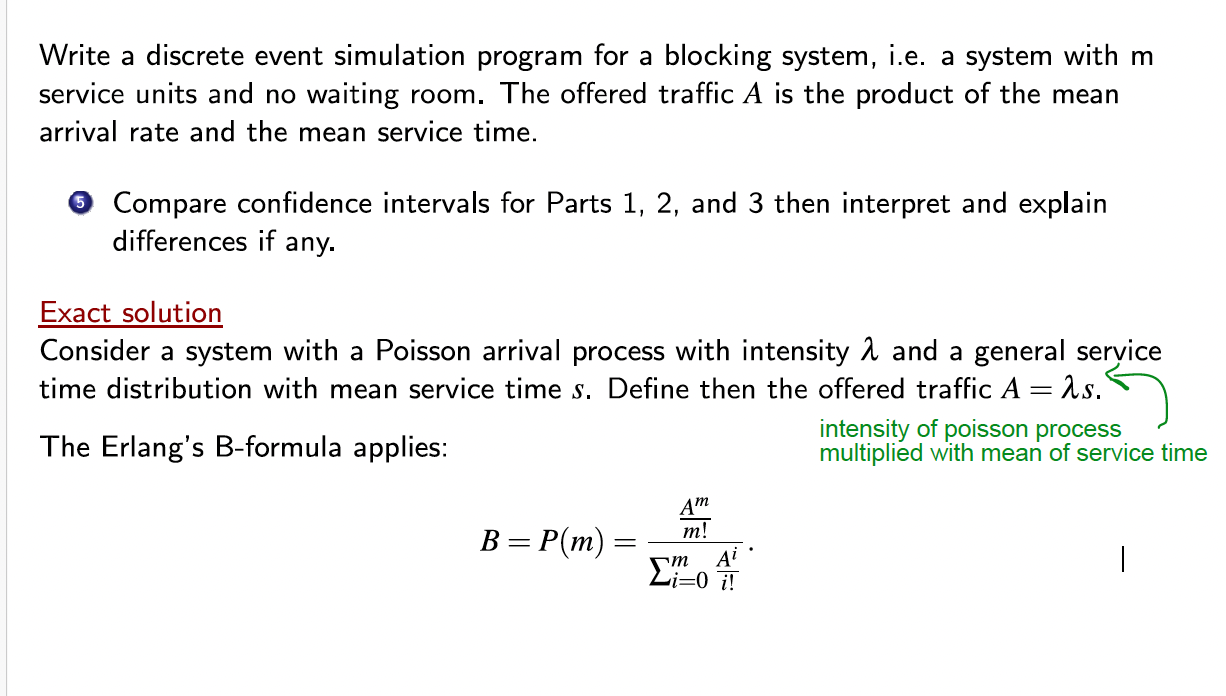

#### I got the following results 

**Normal distributed service time Sim**

Simulated mean blocking: 0.12162

95% CI: [0.11781, 0.12543]

**Uniform distributed service time Sim**

Simulated mean blocking: 0.12142

95% CI: [0.11753, 0.12531]

Alle is close to around 12% blocking rate exepct for k=1.05 and the theoretical is around that as well, som was around 13 some around 9 

# Day 4

## Exercise 5

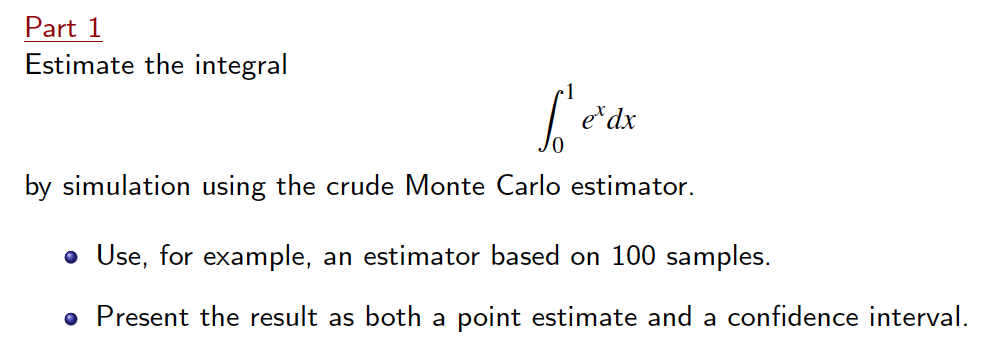

In [151]:
# 
np.random.seed(42)
S = 100

"""
def crude_MC(S):
    f = []
    x =  np.random.rand(S) 
    for i in range(len(x)):
        f.append(np.exp(x))
    E = np.mean(f)
    std = np.std(f)
    return E,std
"""
#Nice and vectorrized

def crude_MC(S):
    x =  np.random.rand(S) 
    f_x = np.exp(x)
    E = np.mean(f_x)
    std = np.std(f_x)
    return E, std

E, std = crude_MC(S)

def CI(mean, std, n):
    alpha = 0.05
    df = n-1
    t_crit = t.ppf(1 - alpha / 2, df)
    ci_lower = mean - t_crit *std/np.sqrt(n)
    ci_upper = mean+ t_crit * std/np.sqrt(n)

    return print(f"95% CI): [{ci_lower:.5f}, {ci_upper:.5f}]")

CI(E, std, S), E

95% CI): [1.57332, 1.77080]


(None, np.float64(1.6720612537554935))

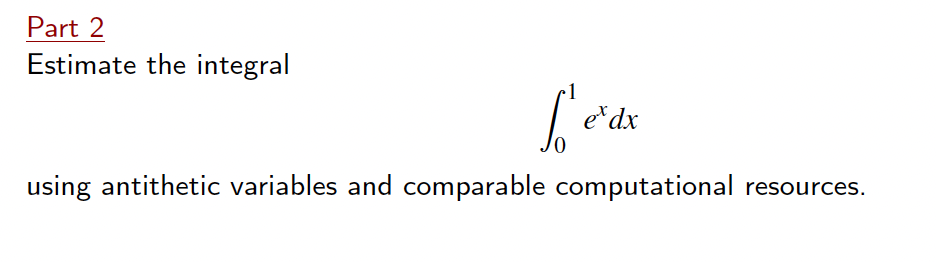

In [155]:
np.random.seed(42)
def antistetic_crude_MC(S):
    x =  np.random.rand(S) 
    f_x = np.exp(x)
    f_anti_x = np.exp(1-x)
    Y= f_x +f_anti_x
    E = np.mean(Y/2)
    std = np.std(Y)
    return E, std

E, std = antistetic_crude_MC(S)

CI(E, std, S), E

95% CI): [1.69790, 1.74731]


(None, np.float64(1.7226021253193073))

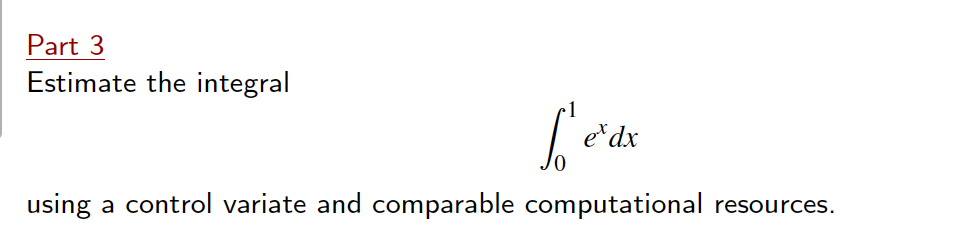

In [159]:
np.random.seed(42)
def control_variate_crude_MC(S):
    c = - 1.69 # see slide 22
    u =  np.random.rand(S) 
    # Y = X +c(U_i - 1/2)
    X = np.exp(u)
    Y = X + c*(u-1/2)
    std = np.std(Y)
    E_Y = np.mean(Y)
    return E_Y, std

E_Y, std = control_variate_crude_MC(S)

CI(E_Y, std, S), E_Y

95% CI): [1.71012, 1.73479]


(None, np.float64(1.7224557974463195))

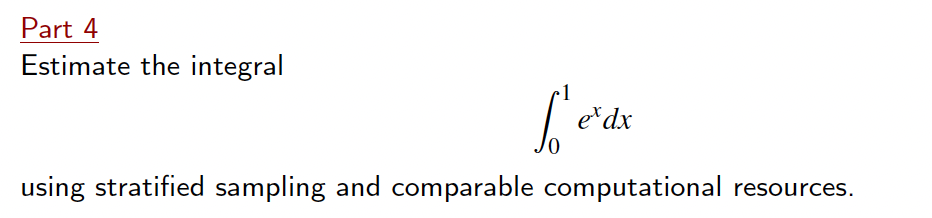

In [165]:
np.random.seed(42)
strata = 10
def stratified_crude_MC(S, strata):
    Y = []
    for i in range(S//strata):
        U =  np.random.rand(strata)
        j = np.arange(1, strata + 1)
        Uij = (j - 1) / strata + (U / strata)
        # Y = 1/strata sum e^Uij
        Yi = 1/strata *np.sum(np.exp(Uij)) 
        Y.append(Yi)
    E_Y = np.mean(Y)
    std = np.std(Y)
    return E_Y, std

E_Y, std = stratified_crude_MC(S, strata)

CI(E_Y, std, S), E_Y

95% CI): [1.70908, 1.71286]


(None, np.float64(1.7109715383144692))

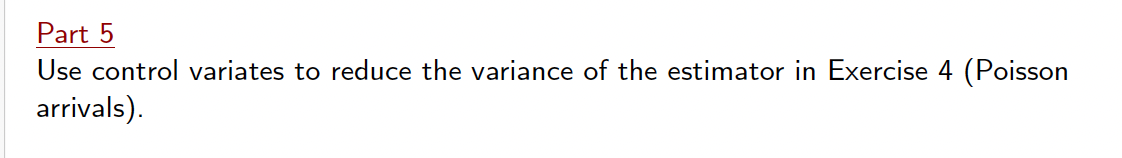

Okay so now we need to change what we did the last time: 

In [181]:
np.random.seed(42)

#ms mean service time
# ma mean arrival time
ms = 8
ma = 1
m = 10
n = 10000

#this time we look at mean service time and this is the one we do control variates with respect to.
def discrete_system_part5(m, ms, ma, n):
    blocked_customers = 0 
    process = np.zeros(m)
    t = 0.0

    service_times_list = []

    for _ in range(n):

        # arrival
        arrival = np.random.exponential(ma)
        t += arrival

        # Set process free after their time
        process[process <= t] = 0

        # Find free process
        idle_process = np.where(process == 0)[0]

        if len(idle_process) > 0:
            process_id = idle_process[0]
            service_time = np.random.exponential(ms)
            process[process_id] = t + service_time
            service_times_list.append(service_time)

        else:
            blocked_customers += 1

    return blocked_customers / n, np.mean(service_times_list)

def control_variate_discrete_system(m, ms, ma, n,k):
    # we make controle variate with respect to arrival times
    B_list = []
    Z_list = []

    mu_Z = ms
    for i in range(k):
        B, Z = discrete_system_part5(m, ms, ma, n) # B = X1 Z = Ui
        B_list.append(B)
        Z_list.append(Z)

    B_list = np.array(B_list)
    Z_list = np.array(Z_list)
    #c = np.cov(B_list, Z_list) #give me a covariance matrix
    c = - np.cov(B_list, Z_list)[0][1]/np.var(Z_list)
    Y = B_list + c*(Z_list -mu_Z)
    
    std = np.std(Y)
    E_Y = np.mean(Y)
    return E_Y, std

E_Y, std = control_variate_discrete_system(m, ms, ma, n, k)
CI(E_Y, std, k), 
print(f"mean: {E_Y}")

95% CI): [0.11936, 0.12165]
mean: 0.12050143799917859


#### my OG code

In [179]:
import heapq
import numpy as np
from scipy.stats import t
import math

np.random.seed(42)
# Parameters
m = 10
mean_service_time = 8 
mean_interarrival_time = 1.0 # time between costumers
runs = 10 
customers_per_run = 10000 # 100.000/runs

#Rates for the esponential distributions, the lambdas
arrival_rate = 1/mean_interarrival_time
service_rate = 1/mean_service_time

A = arrival_rate * mean_service_time

def sbs(m, num_customers, arrival_rate, service_rate):
    #We run one ( out of the 10) Descrete event simulations
    #state variables
    current_time = 0.0
    active_servers = 0.0

    #statistical quantities
    blocked_customers = 0
    total_customers = 0 

    # Event List
    event_list = []
    
    arrival_times_list = []
    #the waiting time from starting to the first costumer arrives follows and exponential distribution
    #current time = 0 in the first arrival case.
    first_arrival = current_time + np.random.exponential(1/arrival_rate)
    #we add the event that the first costumer has arrived to the event list ( time, event)
    heapq.heappush(event_list, (first_arrival, "arrival"))
    # we use heapq in order to make sure we keep the time kronologically, heapq 
    #retrives the tuple from the qeue with the lowest time. 

    # while not all 10.000 customers has arrived. 
    while total_customers < num_customers:
        #in this simpel example this never happens ( the store is open untill all costumers has arrived, but in real life we might have that the store closes and the eventlist is therfore empty).
        if not event_list:
            break

        #We jumpt to ( and exstract) the next event in time. 
        event_time, event_type = heapq.heappop(event_list)
        current_time = event_time

        if event_type == "arrival":
            #next thing that happens in time is that a costumer arrives
            total_customers += 1

            #if the amount of active servers is less than the amount of servers, we have available servers
            if active_servers < m:
                #so the costumer imdeiatly gets service
                active_servers += 1
                # The service distribution time is exponential so it takes expoentially distributed time to give service to a costumer
                departure_time = current_time + np.random.exponential(1/service_rate)
                #we add the event to the event list
                heapq.heappush(event_list, (departure_time, "departure"))
            else: 
                #there are no available servers so we block the costumer
                blocked_customers += 1

            # we now plan for the next costumer arrival ( we dont knwo if this is gonna be before doing or after the first/current costumer gets service.)

            # arrival
            arrival = np.random.exponential(ma)
            arrival_times_list.append(arrival)

            next_arrival_time = current_time + arrival 
            heapq.heappush(event_list, (next_arrival_time, "arrival"))

        elif event_type == "departure":
            #costumers leaves the systems therefore vacading a server
            active_servers -= 1

    #we are asked to report the blocking fraction
    return blocked_customers / total_customers, np.mean(arrival_times_list)


def control_variate_discrete_system(m, ms, ma, n,k):
    # we make controle variate with respect to arrival times
    B_list = []
    Z_list = []

    mu_Z = ma
    for i in range(k):
        B, Z = sbs(m, n, 1/ma, 1/ms) # B = X1 Z = Ui
        B_list.append(B)
        Z_list.append(Z)

    B_list = np.array(B_list)
    Z_list = np.array(Z_list)
    #c = np.cov(B_list, Z_list) #give me a covariance matrix
    c = - np.cov(B_list, Z_list)[0][1]/np.var(Z_list)
    Y = B_list + c*(Z_list -mu_Z)
    
    std = np.std(Y)
    E_Y = np.mean(Y)
    return E_Y, std

E_Y, std = control_variate_discrete_system(m, ms, ma, n, k)
CI(E_Y, std, k), 
print(f"mean: {E_Y}")

95% CI): [0.11953, 0.12219]
mean: 0.12086266857315996


### part 6

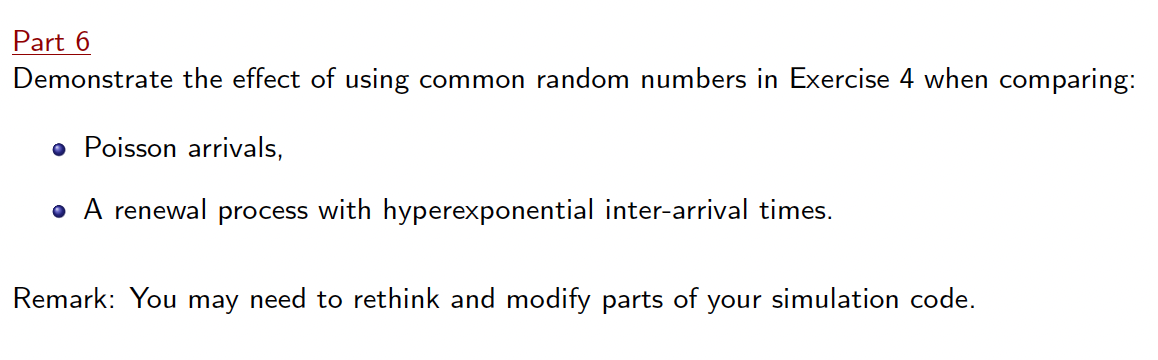

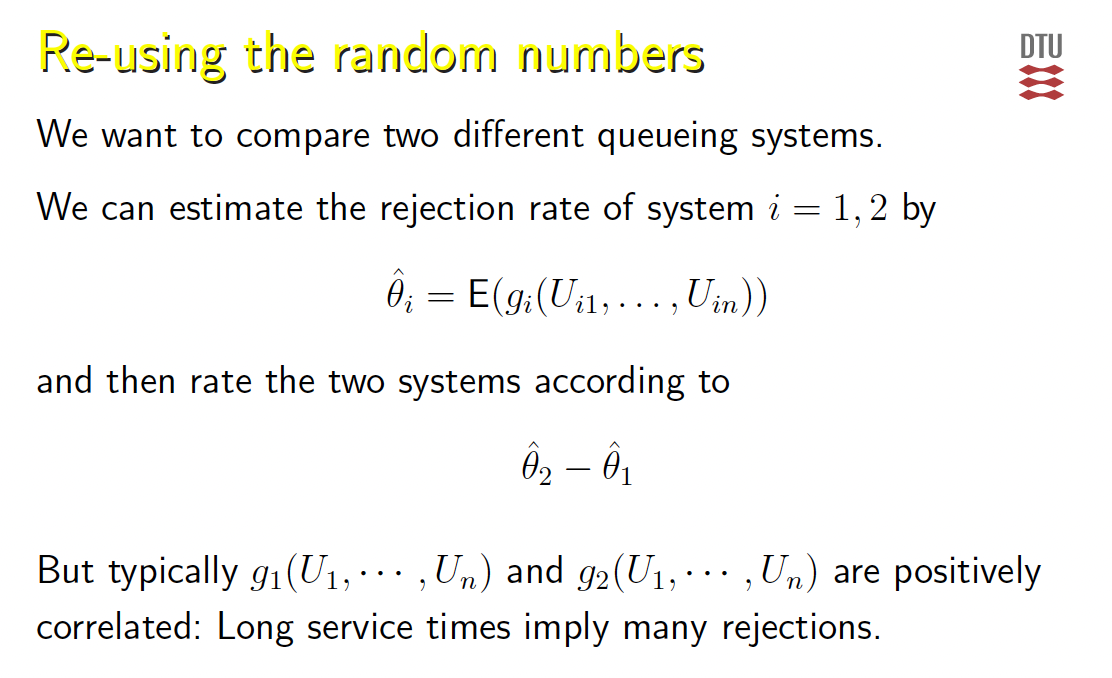
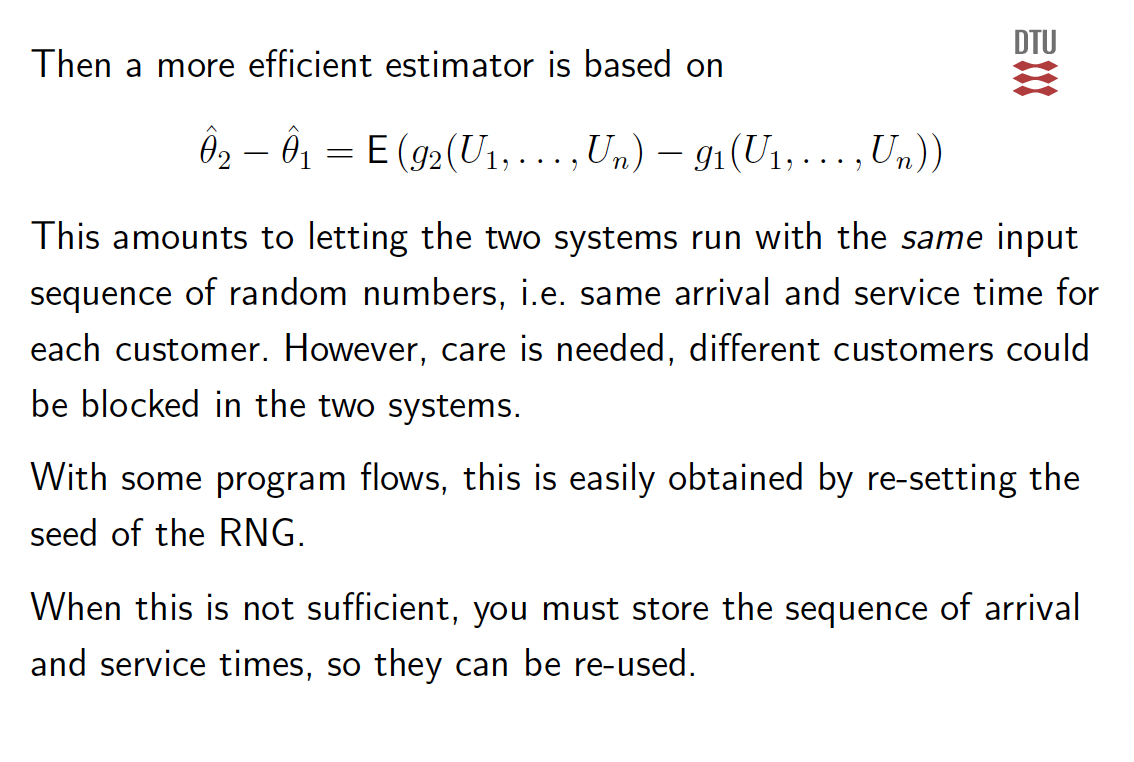

In [184]:
np.random.seed(42)

#ms mean service time
# ma mean arrival time
ms = 8
ma = 1
m = 10
n = 10000
k = 50

### Hyper exponential distribution
p1 = 0.8
lamba1 = 0.83333
p2 = 0.2
lamba2 = 5.0

def exp_samples(lamba, U):
    Y = - np.log(U)/lamba
    return Y

def ds_possion(m, ms, n, list_RN):
    blocked_customers = 0 
    process = np.zeros(m)
    t = 0.0

    arrival_times_list = []

    for i in range(n):
        # arrival
        arrival =  exp_samples(1/ma, list_RN[i]) 
        t += arrival
        arrival_times_list.append(arrival)

        # Set process free after their time
        process[process <= t] = 0

        # Find free process
        idle_process = np.where(process == 0)[0]

        if len(idle_process) > 0:
            process_id = idle_process[0]
            service_time = np.random.exponential(ms)
            process[process_id] = t + service_time

        else:
            blocked_customers += 1

    return blocked_customers / n

def ds_hyperexpo(m, ms, n, list_RN,lamba1, lamba2):
    blocked_customers = 0 
    process = np.zeros(m)
    t = 0.0

    arrival_times_list = []

    for i in range(n):
        u= np.random.rand()
        if u < p1:
            arrival = exp_samples(1/lamba1, list_RN[i])     
        else: 
            arrival = exp_samples(1/lamba2, list_RN[i]) 

        t += arrival
        arrival_times_list.append(arrival)

        # Set process free after their time
        process[process <= t] = 0

        # Find free process
        idle_process = np.where(process == 0)[0]

        if len(idle_process) > 0:
            process_id = idle_process[0]
            service_time = np.random.exponential(ms)
            process[process_id] = t + service_time

        else:
            blocked_customers += 1

    return blocked_customers / n

def common_RN_discrete_system(m, ms, ma, n,k):
    # so we want to compare two queing systems
    list_RN = []
    # We need to have the two programs use the same Random number sequense
    for i in range(n):
        list_RN.append(np.random.rand())


    theta1 = ds_possion(m, ms, ma, n, list_RN) 
    theta2 = ds_hyperexpo(m, ms, ma, n, list_RN) 

    score = theta2-theta1

    mean_score = np.mean(score)
    std = np.std(score)

    return mean_score, std

E_Y, std = common_RN_discrete_system(m, ms, ma, n, k)
CI(E_Y, std, k), 
print(f"mean: {E_Y}")

TypeError: ds_possion() takes 4 positional arguments but 5 were given

###  part 7 

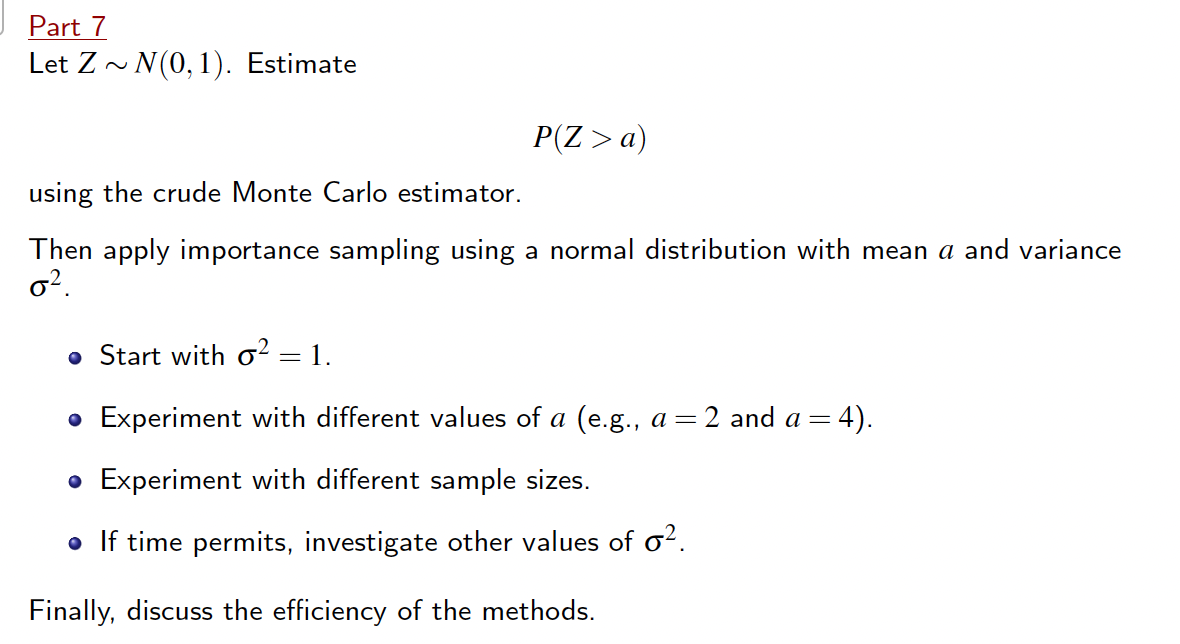

In [236]:
import numpy as np

np.random.seed(42)
n = 10000


def crude_MC_vectorized(a, n):
    Z = np.random.normal(loc=0.0, scale=1.0, size=n)
    p = np.mean(Z > a)
    return p

print(f"Crude MC P(Z > 2): {crude_MC_vectorized(2, n)}")
print(f"Crude MC P(Z > 4): {crude_MC_vectorized(4, n)}")




Crude MC P(Z > 2): 0.0237
Crude MC P(Z > 4): 0.0001


In [235]:
import numpy as np
from scipy.stats import norm

np.random.seed(42)
a = 2
sigma = 1
n = 10000


def importance_sampling(a, sigma, n):
    # Y has density g
    Y = np.random.normal(loc=a, scale=sigma, size=n)
    # f is distribution we test (Z)
    f_pdf = norm.pdf(Y, loc=0.0, scale=1.0)
    # g is the one we create that is larger or equal to f.
    g_pdf = norm.pdf(Y, loc=a, scale=sigma)
    h_Y = Y > a
    E_h = np.mean(h_Y * f_pdf / g_pdf)
    return E_h

print(f"Importance Sampling P(Z > 2): {importance_sampling(2, 1, n):.6f}")


Importance Sampling P(Z > 2): 0.022755


In [246]:
np.random.seed(42)
n_list= np.array([10, 100, 1000, 10000, 100000])
for i in range(len(n_list)):
    print(f"n:{n_list[i]}")
    print(f"Crude MC P(Z > 2): {crude_MC_vectorized(2, n_list[i])}")
    print(f"Crude MC P(Z > 4): {crude_MC_vectorized(4, n_list[i])}")
    print(f"Importance Sampling P(Z > 2): {importance_sampling(2, 1, n_list[i]):.6f}")


n:10
Crude MC P(Z > 2): 0.0
Crude MC P(Z > 4): 0.0
Importance Sampling P(Z > 2): 0.029770
n:100
Crude MC P(Z > 2): 0.02
Crude MC P(Z > 4): 0.0
Importance Sampling P(Z > 2): 0.025084
n:1000
Crude MC P(Z > 2): 0.028
Crude MC P(Z > 4): 0.0
Importance Sampling P(Z > 2): 0.022013
n:10000
Crude MC P(Z > 2): 0.023
Crude MC P(Z > 4): 0.0001
Importance Sampling P(Z > 2): 0.023039
n:100000
Crude MC P(Z > 2): 0.02292
Crude MC P(Z > 4): 1e-05
Importance Sampling P(Z > 2): 0.022597


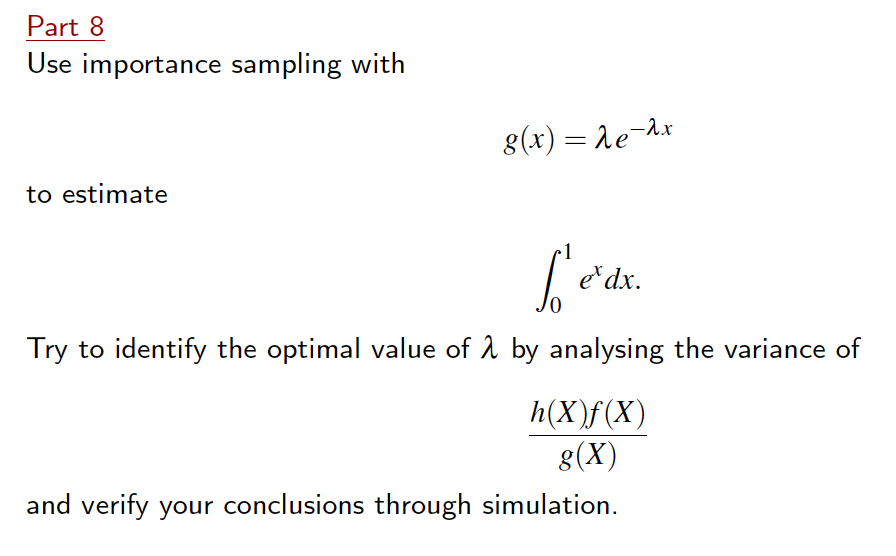

In [259]:
import numpy as np
from scipy.stats import norm

np.random.seed(42)
a = 2
sigma = 1
n = 10000
lamba = 1

#from earlier
def exp_samples(lamba, S):
    U = np.random.rand(S) 
    Y = - np.log(U)/lamba
    return Y

def crude_MC(S):
    x =  np.random.rand(S) 
    f_x = np.exp(x)
    E = np.mean(f_x)
    std = np.std(f_x)
    return E, std


def importance_sampling_part8(lamba,n):
    # Y has density g #this is like the pdf
    X = exp_samples(lamba, n)

    # h is like the thing in the integral
    h_X = np.exp(X)
    # f(X) is standard uniform PDF: 1 if 0 <= X <= 1, else 0
    f_X = np.where((X >= 0) & (X <= 1), 1.0, 0.0)
    g_X = lamba * np.exp(-lamba * X)

    var_frac=np.var(h_X*f_X /g_X)
    E = np.mean(h_X * f_X / g_X)
    return E, var_frac


lambds= np.linspace(0.01,100,1000)
best_lambda = None
lowest_varience = np.inf

for l in lambds:
    E, var_frac = importance_sampling_part8(l, n)
    if var_frac <lowest_varience:
        lowest_varience = var_frac
        best_lambda = l

    # print(f"Importance Sampling mean: {E:.6f}")
    # print(f"Importance Sampling var frac : {var_frac:.6f}")


print(best_lambda, lowest_varience)



86.28765765765766 0.1831816980933598


/var/folders/k2/rp7vstcj1w3b1b5ldyntqfkr0000gn/T/ipykernel_84264/3250071924.py:29: RuntimeWarning: overflow encountered in exp
  h_X = np.exp(X)
/var/folders/k2/rp7vstcj1w3b1b5ldyntqfkr0000gn/T/ipykernel_84264/3250071924.py:34: RuntimeWarning: invalid value encountered in multiply
  var_frac=np.var(h_X*f_X /g_X)
/var/folders/k2/rp7vstcj1w3b1b5ldyntqfkr0000gn/T/ipykernel_84264/3250071924.py:35: RuntimeWarning: invalid value encountered in multiply
  E = np.mean(h_X * f_X / g_X)


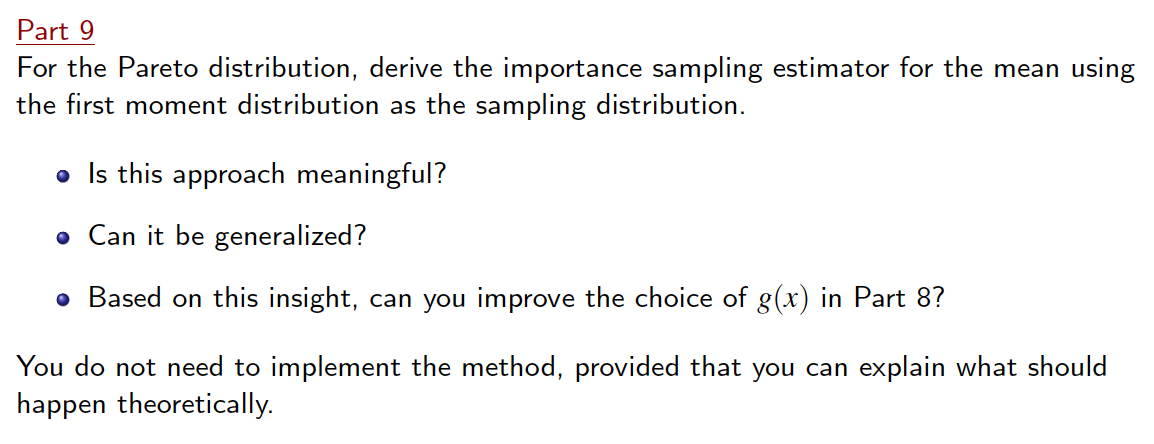